In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, ShuffleSplit, learning_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, silhouette_score
from imblearn.over_sampling import SMOTE
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from geopy.distance import great_circle
from shapely.geometry import MultiPoint
from scipy.spatial import cKDTree
from sklearn.cluster import DBSCAN



In [50]:

#load all csv file
df_CL = pd.read_csv("crash_locations.csv")
df_DI = pd.read_csv("driver_involvement.csv")
df_FIRC = pd.read_csv("factor_in_road_crash.csv")
df_HU = pd.read_csv("helmet_use.csv")
df_RC = pd.read_csv("road_casualties.csv")
df_VI = pd.read_csv("vehicle_involvement.csv")
df_hf = pd.read_csv("high_rainfall.csv")
df_r100 = pd.read_csv("roughness_100m.csv")
file_list=[df_CL,df_DI,df_FIRC,df_HU,df_RC,df_VI]
#check the file successful load
for x in file_list:
    column_names = x.columns.tolist()
    print(column_names)
print(df_CL.head())
column_names=df_hf.columns.tolist()
print(column_names)

C:\Users\29084\AppData\Local\Temp\ipykernel_6368\2719910160.py:2: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df_CL = pd.read_csv("crash_locations.csv")


['Crash_Ref_Number', 'Crash_Severity', 'Crash_Year', 'Crash_Month', 'Crash_Day_Of_Week', 'Crash_Hour', 'Crash_Nature', 'Crash_Type', 'Crash_Longitude', 'Crash_Latitude', 'Crash_Street', 'Crash_Street_Intersecting', 'State_Road_Name', 'Loc_Suburb', 'Loc_Local_Government_Area', 'Loc_Post_Code', 'Loc_Police_Division', 'Loc_Police_District', 'Loc_Police_Region', 'Loc_Queensland_Transport_Region', 'Loc_Main_Roads_Region', 'Loc_ABS_Statistical_Area_2', 'Loc_ABS_Statistical_Area_3', 'Loc_ABS_Statistical_Area_4', 'Loc_ABS_Remoteness', 'Loc_State_Electorate', 'Loc_Federal_Electorate', 'Crash_Controlling_Authority', 'Crash_Roadway_Feature', 'Crash_Traffic_Control', 'Crash_Speed_Limit', 'Crash_Road_Surface_Condition', 'Crash_Atmospheric_Condition', 'Crash_Lighting_Condition', 'Crash_Road_Horiz_Align', 'Crash_Road_Vert_Align', 'Crash_DCA_Code', 'Crash_DCA_Description', 'Crash_DCA_Group_Description', 'DCA_Key_Approach_Dir', 'Count_Casualty_Fatality', 'Count_Casualty_Hospitalised', 'Count_Casualty_M

In [13]:
print(df_CL.describe(include='all'))
rows, columns = df_CL.shape
print(f" {rows}row and {columns} column")

        Crash_Ref_Number     Crash_Severity     Crash_Year Crash_Month  \
count      380316.000000             380316  380316.000000      380316   
unique               NaN                  5            NaN          12   
top                  NaN  Medical treatment            NaN      August   
freq                 NaN             118909            NaN       33865   
mean       190158.500000                NaN    2009.946839         NaN   
std        109787.916826                NaN       6.230248         NaN   
min             1.000000                NaN    2001.000000         NaN   
25%         95079.750000                NaN    2005.000000         NaN   
50%        190158.500000                NaN    2009.000000         NaN   
75%        285237.250000                NaN    2015.000000         NaN   
max        380316.000000                NaN    2023.000000         NaN   

       Crash_Day_Of_Week     Crash_Hour Crash_Nature     Crash_Type  \
count             380316  380316.000000 

In [14]:
#learning curve to check the  DF_HU and DF_RC dataframe(feature select the frist one is Crash_Year),
#maybe delete Crash_year column to recheck(5.5)

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None,
                        n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, color="r", alpha=0.1)
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, color="g", alpha=0.1)
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")
    plt.legend(loc="best")
    return plt

# need check later and understand that part

In [15]:
# before the combination to the data clean, replicate and null value
df_CL.dropna(inplace=True)
duplicates = df_CL.duplicated()
print("Number of duplicate rows:", duplicates.sum())
# check the duplicate number
if duplicates.sum() > 0:
    print(df_CL[duplicates])
df_r100.dropna(inplace=True)# choose 100m road section, 1000m may not accurate(3.11)
duplicates = df_r100.duplicated()
print("Number of duplicate rows:", duplicates.sum())
if duplicates.sum() > 0:
    print(df_r100[duplicates])


Number of duplicate rows: 0
Number of duplicate rows: 0


In [16]:
# based on the latitude and longitude combination
# Convert the relevant columns to a numpy array for faster computation
coords1 = df_CL[['Crash_Latitude', 'Crash_Longitude']].to_numpy()
coords2 = df_r100[['Latitude', 'Longitude']].to_numpy()

# Create a KDTree 
tree = cKDTree(coords2)
#for each point in dataset1 to find the closest point in dataset2
distances, indices = tree.query(coords1, k=1)
# 0.01 maximum distance 
max_distance = 0.01
valid_matches = distances <= max_distance

# Use closest points to merge the datasets
matched_dataset1 = df_CL[valid_matches]
matched_dataset2 = df_r100.iloc[indices[valid_matches]]
# Resetting index to allow for a clean concatenation
matched_dataset1.reset_index(drop=True, inplace=True)
matched_dataset2.reset_index(drop=True, inplace=True)
# Combining the datasets. 
combined_dataset = pd.concat([matched_dataset1, matched_dataset2], axis=1)
print(combined_dataset.columns)


Index(['Crash_Ref_Number', 'Crash_Severity', 'Crash_Year', 'Crash_Month',
       'Crash_Day_Of_Week', 'Crash_Hour', 'Crash_Nature', 'Crash_Type',
       'Crash_Longitude', 'Crash_Latitude', 'Crash_Street',
       'Crash_Street_Intersecting', 'State_Road_Name', 'Loc_Suburb',
       'Loc_Local_Government_Area', 'Loc_Post_Code', 'Loc_Police_Division',
       'Loc_Police_District', 'Loc_Police_Region',
       'Loc_Queensland_Transport_Region', 'Loc_Main_Roads_Region',
       'Loc_ABS_Statistical_Area_2', 'Loc_ABS_Statistical_Area_3',
       'Loc_ABS_Statistical_Area_4', 'Loc_ABS_Remoteness',
       'Loc_State_Electorate', 'Loc_Federal_Electorate',
       'Crash_Controlling_Authority', 'Crash_Roadway_Feature',
       'Crash_Traffic_Control', 'Crash_Speed_Limit',
       'Crash_Road_Surface_Condition', 'Crash_Atmospheric_Condition',
       'Crash_Lighting_Condition', 'Crash_Road_Horiz_Align',
       'Crash_Road_Vert_Align', 'Crash_DCA_Code', 'Crash_DCA_Description',
       'Crash_DCA_Group_De

In [17]:
df = pd.read_csv('combined_dataset.csv')
#print(df.columns)
#use combined dataset to draw the graph
#use tableau draw(4.18)
result = df.groupby(['Crash_Severity', 'RoughnessClass', 'Crash_Latitude', 'Crash_Longitude']).size().reset_index(name='count')
#clean null value
df.dropna(inplace=True)
df_cd= df
print(result)



              Crash_Severity RoughnessClass  Crash_Latitude  Crash_Longitude  \
0                      Fatal      0 No data      -28.675155       151.920917   
1                      Fatal      0 No data      -28.395276       150.314120   
2                      Fatal      0 No data      -28.122449       152.067184   
3                      Fatal      0 No data      -28.122367       152.067224   
4                      Fatal      0 No data      -28.082260       153.359771   
...                      ...            ...             ...              ...   
280458  Property damage only   6 Unsurfaced      -14.270510       143.301782   
280459  Property damage only   6 Unsurfaced      -13.614088       143.054465   
280460  Property damage only   6 Unsurfaced      -13.085166       142.742450   
280461  Property damage only   6 Unsurfaced      -12.981323       142.443329   
280462  Property damage only   6 Unsurfaced      -12.691571       142.334394   

        count  
0           1  
1      

In [18]:
# import pandas as pd


# duplicates = df.duplicated()
# print("Number of duplicate rows:", duplicates.sum())

# if duplicates.sum() > 0:
#     print(df[duplicates])


NAASRARoughness: 0.231
IRIRoughness: 0.167
Count_Casualty_Hospitalised: 0.152
Count_Casualty_MedicallyTreated: 0.149
Count_Casualty_Total: 0.128
Count_Casualty_MinorInjury: 0.066
RoughnessSurveyDate: 0.019
Crash_Year: 0.016
Crash_Ref_Number: 0.006
Count_Casualty_Fatality: 0.006
Crash_DCA_Group_Description: 0.004
TDIST_END: 0.003
TDIST_START: 0.003
Crash_DCA_Description: 0.003
APRoad100mID: 0.003
Longitude: 0.003
Crash_Longitude: 0.003
Crash_Nature: 0.003
Crash_Latitude: 0.002
Latitude: 0.002
Count_Unit_Motorcycle_Moped: 0.002
ROAD_SECTION_ID: 0.002
Loc_Post_Code: 0.002
State_Road_Name: 0.002
Count_Unit_Car: 0.002
Crash_DCA_Code: 0.001
CARRIAGEWAY_CODE: 0.001
SEGMENT_LENGTH: 0.001
Loc_Suburb: 0.001
Loc_ABS_Statistical_Area_2: 0.001
Crash_Street_Intersecting: 0.001
Loc_ABS_Statistical_Area_3: 0.001
Crash_Street: 0.001
Loc_ABS_Statistical_Area_4: 0.001
Loc_State_Electorate: 0.001
Loc_Police_Division: 0.001
Count_Unit_Bicycle: 0.001
Crash_Roadway_Feature: 0.001
Loc_Police_District: 0.001
L

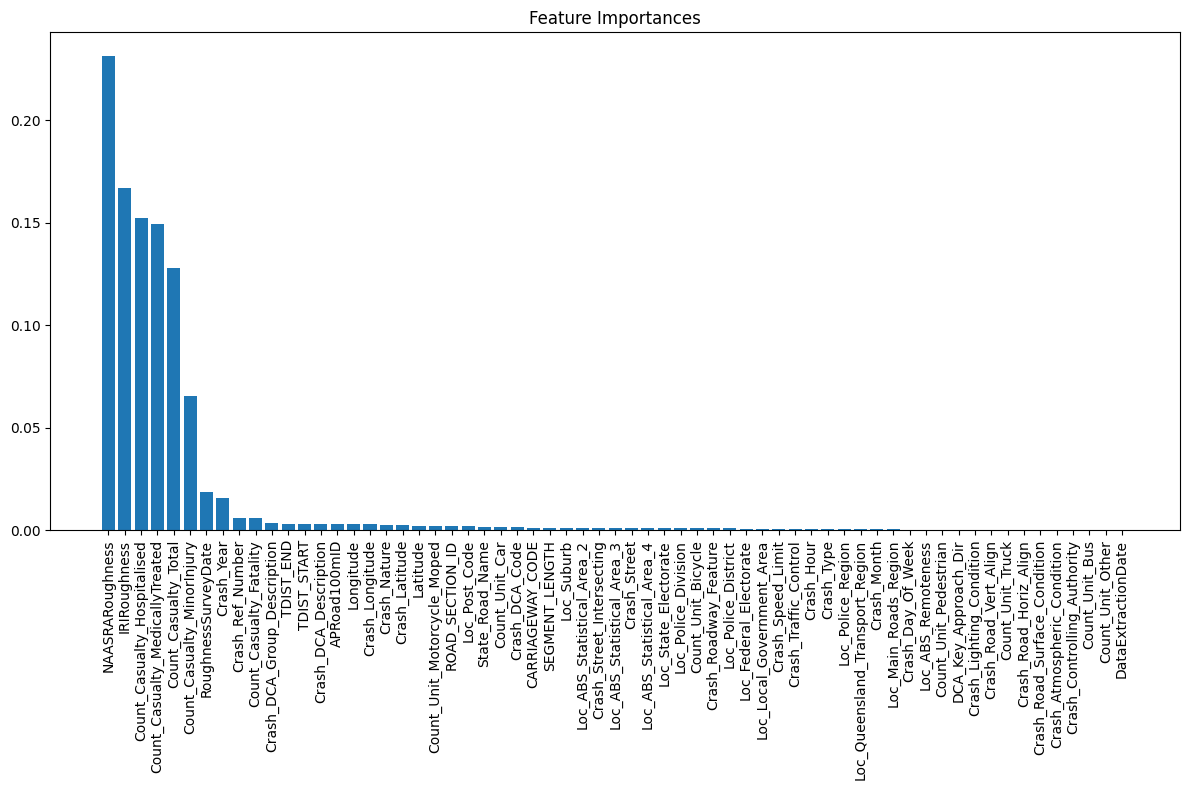

Index(['Crash_Ref_Number', 'Crash_Severity', 'Crash_Year', 'Crash_Month',
       'Crash_Day_Of_Week', 'Crash_Hour', 'Crash_Nature', 'Crash_Type',
       'Crash_Longitude', 'Crash_Latitude', 'Crash_Street',
       'Crash_Street_Intersecting', 'State_Road_Name', 'Loc_Suburb',
       'Loc_Local_Government_Area', 'Loc_Post_Code', 'Loc_Police_Division',
       'Loc_Police_District', 'Loc_Police_Region',
       'Loc_Queensland_Transport_Region', 'Loc_Main_Roads_Region',
       'Loc_ABS_Statistical_Area_2', 'Loc_ABS_Statistical_Area_3',
       'Loc_ABS_Statistical_Area_4', 'Loc_ABS_Remoteness',
       'Loc_State_Electorate', 'Loc_Federal_Electorate',
       'Crash_Controlling_Authority', 'Crash_Roadway_Feature',
       'Crash_Traffic_Control', 'Crash_Speed_Limit',
       'Crash_Road_Surface_Condition', 'Crash_Atmospheric_Condition',
       'Crash_Lighting_Condition', 'Crash_Road_Horiz_Align',
       'Crash_Road_Vert_Align', 'Crash_DCA_Code', 'Crash_DCA_Description',
       'Crash_DCA_Group_De

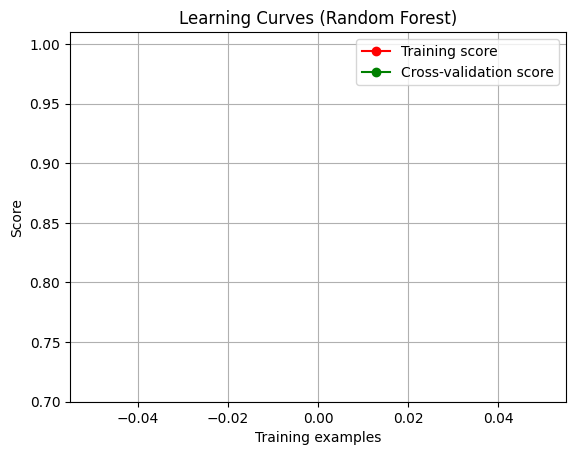

In [19]:

# featrue select combined dataset
#severity forcast (these column not useful)
data = df_cd#.drop(['RoughnessSurveyDate','Crash_Ref_Number', 'Crash_Longitude', 'Crash_Latitude', 'State_Road_Name', 'Loc_Suburb', 'Loc_ABS_Statistical_Area_2', 'Loc_ABS_Statistical_Area_3', 'Loc_ABS_Statistical_Area_4', 'Loc_ABS_Remoteness', 'Count_Unit_Truck', 'Count_Unit_Bus', 'Count_Unit_Bicycle', 'Count_Unit_Pedestrian', 'Count_Unit_Other', 'APRoad100mID'], axis=1)

# data pre processing
# assume all column use encoding(label encoding or one hot encoding? check later(4.21))
# try label, not all column nned encoding
columns_not_to_encode = ['Crash_Year', 'Crash_month','Crash_Hour','NAASRARoughness','IRIRoughness']
label_encoders = {}
for column in data.columns:
    if column not in columns_not_to_encode:
        if data[column].dtype == object:
            le = LabelEncoder()
            data[column] = le.fit_transform(data[column])
            label_encoders[column] = le
#IQR to check the outlier(maybe not need, check later)
"""Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
data = data[~((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).any(axis=1)]"""
numeric_columns = data.select_dtypes(include=['float64', 'int64']).columns

# calculate Q1 Q3
Q1 = data[numeric_columns].quantile(0.25)
Q3 = data[numeric_columns].quantile(0.75)
IQR = Q3 - Q1

# based on IQR reduce outlier
data_cleaned = data[~((data[numeric_columns] < (Q1 - 1.5 * IQR)) | (data[numeric_columns] > (Q3 + 1.5 * IQR))).any(axis=1)]
# split data
X = data.drop(['Crash_Severity', 'RoughnessClass'], axis=1)  # assume crash_severity   # assume Roughness Class
y = data[['Crash_Severity', 'RoughnessClass']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42,max_depth=10)# use 100, maybe need more
model.fit(X_train, y_train)
importances = model.feature_importances_
features = X.columns
importance_threshold = 0.01
important_indices = importances > importance_threshold
important_features2 = features[important_indices]
important_importances = importances[important_indices]

# sort and print
sorted_indices = importances.argsort()[::-1]
for index in sorted_indices:
    print(f"{features[index]}: {importances[index]:.3f}")
plt.figure(figsize=(12, 8))
plt.title('Feature Importances')
plt.bar(range(X.shape[1]), importances[sorted_indices], align='center')
plt.xticks(range(X.shape[1]), [features[i] for i in sorted_indices], rotation=90)
plt.tight_layout()
plt.show()
print(df_cd.columns)
#if just crash severity------Count_Casualty_MedicallyTreated
# add rough class NAASRARoughness become first one

title = "Learning Curves (Random Forest)"
cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=0)
plot_learning_curve(model, title, X, y, ylim=(0.7, 1.01), cv=cv, n_jobs=4)
plt.show()

NAASRARoughness: 0.409
IRIRoughness: 0.362
Crash_Year: 0.064
Crash_DCA_Description: 0.012
Loc_Post_Code: 0.011
TDIST_END: 0.010
ROAD_SECTION_ID: 0.009
Crash_DCA_Code: 0.009
Crash_Nature: 0.009
TDIST_START: 0.009
Crash_Street: 0.008
Crash_Street_Intersecting: 0.008
Crash_DCA_Group_Description: 0.008
Loc_State_Electorate: 0.006
Loc_Police_Division: 0.006
Crash_Hour: 0.005
Loc_Federal_Electorate: 0.005
Loc_Police_District: 0.005
Loc_Local_Government_Area: 0.004
CARRIAGEWAY_CODE: 0.004
Crash_Roadway_Feature: 0.004
Crash_Month: 0.004
Count_Unit_Car: 0.003
Crash_Traffic_Control: 0.003
Crash_Day_Of_Week: 0.003
Crash_Speed_Limit: 0.003
Loc_Police_Region: 0.003
Loc_Queensland_Transport_Region: 0.003
Loc_Main_Roads_Region: 0.002
DCA_Key_Approach_Dir: 0.002
Crash_Lighting_Condition: 0.001
Crash_Type: 0.001
Crash_Road_Vert_Align: 0.001
Crash_Road_Horiz_Align: 0.001
Crash_Road_Surface_Condition: 0.001
Crash_Atmospheric_Condition: 0.001
Crash_Controlling_Authority: 0.000
SEGMENT_LENGTH: 0.000
Count_

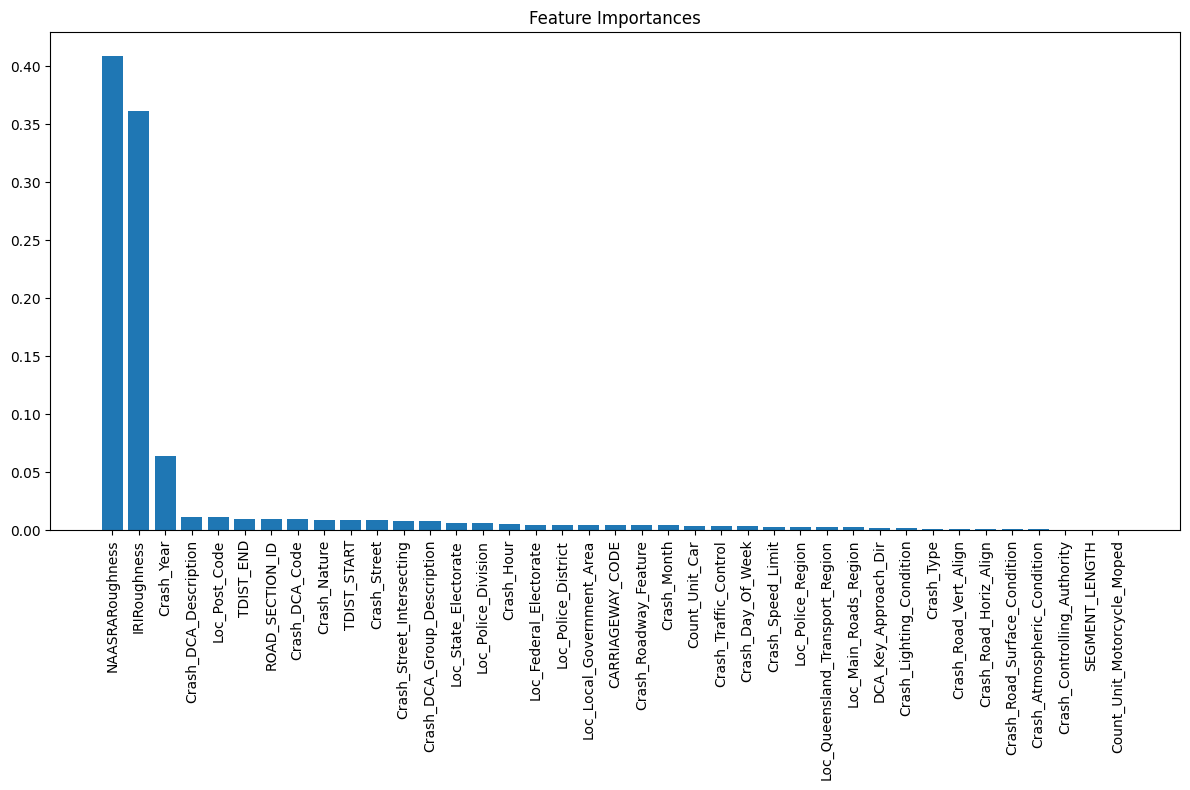

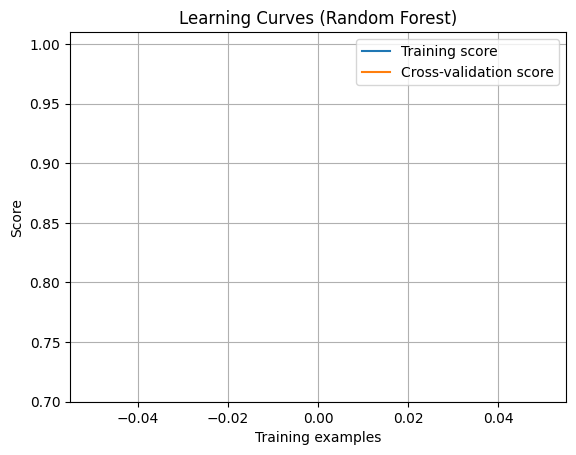

In [ ]:

# Load your data
# df_cd = pd.read_csv('path_to_your_combined_dataset.csv') # Uncomment if loading from file

# Drop columns not useful for severity forecast
data = df_cd.drop([
    'RoughnessSurveyDate', 'Crash_Ref_Number', 'Crash_Longitude', 'Crash_Latitude', 
    'State_Road_Name', 'Loc_Suburb', 'Loc_ABS_Statistical_Area_2', 'Loc_ABS_Statistical_Area_3', 
    'Loc_ABS_Statistical_Area_4', 'Loc_ABS_Remoteness', 'Count_Unit_Truck', 'Count_Unit_Bus', 
    'Count_Unit_Bicycle', 'Count_Unit_Pedestrian', 'Count_Unit_Other', 'APRoad100mID','Count_Casualty_Fatality','Count_Casualty_Hospitalised','Count_Casualty_MedicallyTreated','Count_Casualty_MinorInjury','Count_Casualty_Total','DataExtractionDate','Latitude','Longitude'
], axis=1)

# Data Preprocessing - Label Encoding
columns_not_to_encode = ['Crash_Year', 'Crash_month', 'Crash_Hour', 'NAASRARoughness', 'IRIRoughness']
label_encoders = {}
for column in data.columns:
    if column not in columns_not_to_encode and data[column].dtype == object:
        le = LabelEncoder()
        data[column] = le.fit_transform(data[column])
        label_encoders[column] = le

# IQR-based Outlier Removal
numeric_columns = data.select_dtypes(include=['float64', 'int64']).columns
Q1 = data[numeric_columns].quantile(0.25)
Q3 = data[numeric_columns].quantile(0.75)
IQR = Q3 - Q1
data_cleaned = data[~((data[numeric_columns] < (Q1 - 1.5 * IQR)) | (data[numeric_columns] > (Q3 + 1.5 * IQR))).any(axis=1)]

# Split data into features (X) and target (y)
X = data_cleaned.drop(['Crash_Severity', 'RoughnessClass'], axis=1)
y = data_cleaned[['Crash_Severity', 'RoughnessClass']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Model Training and Feature Importance
model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
model.fit(X_train, y_train)
importances = model.feature_importances_
features = X.columns

# Feature Importance Threshold and Selection
importance_threshold = 0.01
important_indices = importances > importance_threshold
important_features = features[important_indices]
important_importances = importances[important_indices]

# Sort and Display Feature Importances
sorted_indices = np.argsort(importances)[::-1]
for index in sorted_indices:
    print(f"{features[index]}: {importances[index]:.3f}")

# Plot Feature Importances
plt.figure(figsize=(12, 8))
plt.title('Feature Importances')
plt.bar(range(X.shape[1]), importances[sorted_indices], align='center')
plt.xticks(range(X.shape[1]), [features[i] for i in sorted_indices], rotation=90)
plt.tight_layout()
plt.show()

# Learning Curve Plotting
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None, n_jobs=None):
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=np.linspace(0.1, 1.0, 5)
    )
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    plt.plot(train_sizes, train_scores_mean, label="Training score")
    plt.plot(train_sizes, test_scores_mean, label="Cross-validation score")
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.legend(loc="best")
    plt.grid()
    plt.show()

# Define Cross-validation and plot learning curves
cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=0)
plot_learning_curve(model, "Learning Curves (Random Forest)", X, y, ylim=(0.7, 1.01), cv=cv, n_jobs=4)


Initial Accuracy: 0.3823


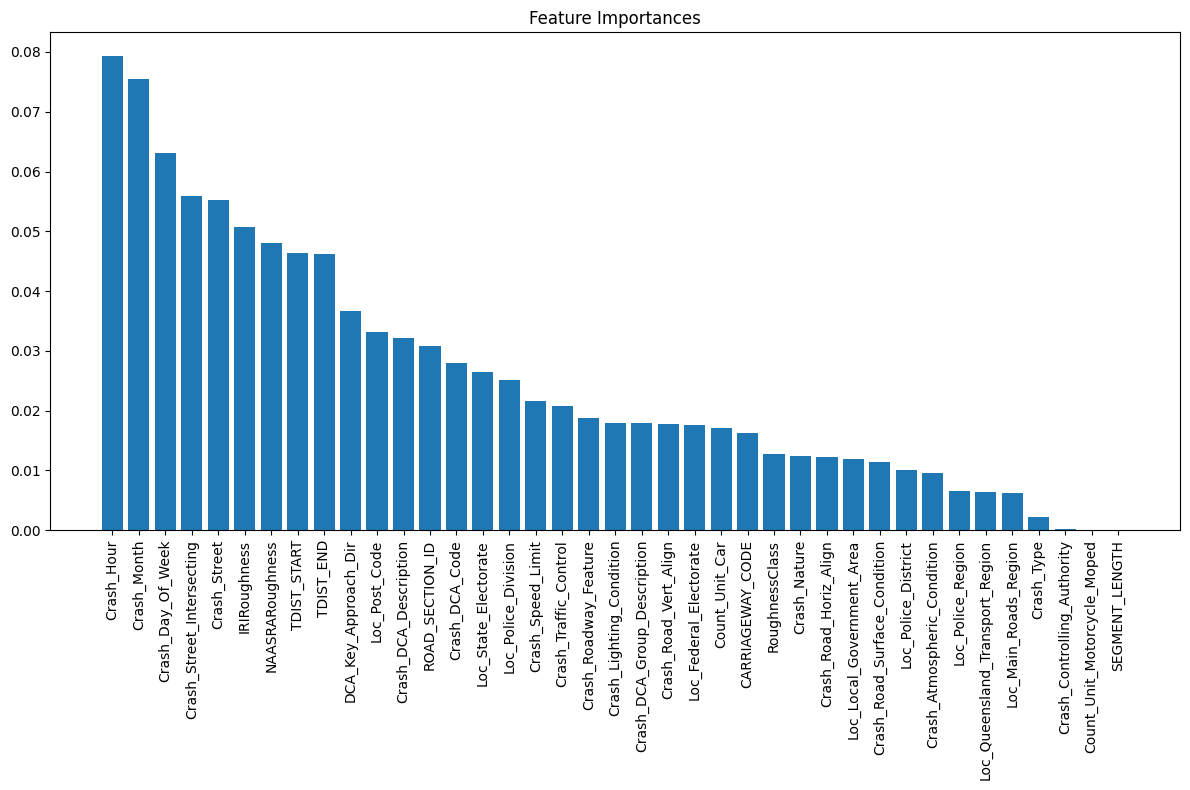

Accuracy after Feature Selection: 0.3661


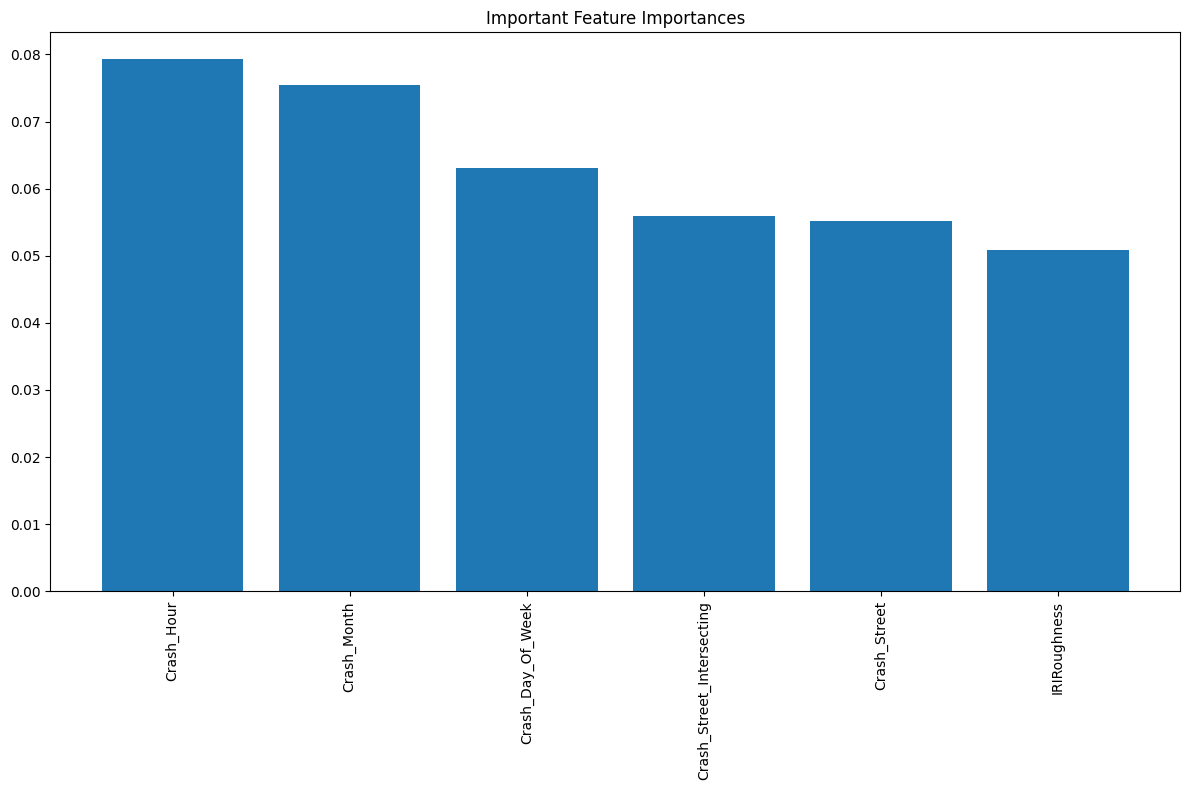

In [ ]:



data = df_cd.drop([
    'RoughnessSurveyDate', 'Crash_Ref_Number', 'Crash_Longitude', 'Crash_Latitude', 
    'State_Road_Name', 'Loc_Suburb', 'Loc_ABS_Statistical_Area_2', 'Loc_ABS_Statistical_Area_3', 
    'Loc_ABS_Statistical_Area_4', 'Loc_ABS_Remoteness', 'Count_Unit_Truck', 'Count_Unit_Bus', 
    'Count_Unit_Bicycle', 'Count_Unit_Pedestrian', 'Count_Unit_Other', 'APRoad100mID','Count_Casualty_Fatality','Count_Casualty_Hospitalised','Count_Casualty_MedicallyTreated','Count_Casualty_MinorInjury','Count_Casualty_Total','DataExtractionDate','Latitude','Longitude','Crash_Year'
], axis=1)
# list no label encoding column
columns_not_to_encode = ['Crash_Year', 'Crash_Month', 'Crash_Hour', 'NAASRARoughness', 'IRIRoughness']

# Label Encoding
label_encoders = {}
for column in data.columns:
    if column not in columns_not_to_encode and data[column].dtype == object:
        le = LabelEncoder()
        data[column] = le.fit_transform(data[column])
        label_encoders[column] = le

# IQR outlier
numeric_columns = data.select_dtypes(include=['float64', 'int64']).columns
Q1 = data[numeric_columns].quantile(0.25)
Q3 = data[numeric_columns].quantile(0.75)
IQR = Q3 - Q1

# based on IQR reduce outlier
data_cleaned = data[~((data[numeric_columns] < (Q1 - 1.5 * IQR)) | (data[numeric_columns] > (Q3 + 1.5 * IQR))).any(axis=1)]

# splite the feature and target variable
X = data_cleaned.drop('Crash_Severity', axis=1)  
y = data_cleaned['Crash_Severity']  

# split trainset and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# initial modeling train
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# initial modelling evaluation
y_pred = model.predict(X_test)
initial_accuracy = accuracy_score(y_test, y_pred)
print(f"Initial Accuracy: {initial_accuracy:.4f}")

# extract feature importance
importances = model.feature_importances_
features = X.columns
sorted_indices = importances.argsort()[::-1]

# visualisation
plt.figure(figsize=(12, 8))
plt.title('Feature Importances')
plt.bar(range(X.shape[1]), importances[sorted_indices], align='center')
plt.xticks(range(X.shape[1]), [features[i] for i in sorted_indices], rotation=90)
plt.tight_layout()
plt.show()

# select the important one
importance_threshold = 0.05
important_indices = importances > importance_threshold
important_features = features[important_indices]

# retrain
X_train_important = X_train[important_features]
X_test_important = X_test[important_features]

model_important = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
model_important.fit(X_train_important, y_train)

# evaluation
y_pred_important = model_important.predict(X_test_important)
important_accuracy = accuracy_score(y_test, y_pred_important)
print(f"Accuracy after Feature Selection: {important_accuracy:.4f}")

# visualisation
important_importances = importances[important_indices]
sorted_important_indices = important_importances.argsort()[::-1]
plt.figure(figsize=(12, 8))
plt.title('Important Feature Importances')
plt.bar(range(len(important_features)), important_importances[sorted_important_indices], align='center')
plt.xticks(range(len(important_features)), [important_features[i] for i in sorted_important_indices], rotation=90)
plt.tight_layout()
plt.show()




In [26]:
print(data.columns)


Index(['Crash_Severity', 'Crash_Month', 'Crash_Day_Of_Week', 'Crash_Hour',
       'Crash_Nature', 'Crash_Type', 'Crash_Street',
       'Crash_Street_Intersecting', 'Loc_Local_Government_Area',
       'Loc_Post_Code', 'Loc_Police_Division', 'Loc_Police_District',
       'Loc_Police_Region', 'Loc_Queensland_Transport_Region',
       'Loc_Main_Roads_Region', 'Loc_State_Electorate',
       'Loc_Federal_Electorate', 'Crash_Controlling_Authority',
       'Crash_Roadway_Feature', 'Crash_Traffic_Control', 'Crash_Speed_Limit',
       'Crash_Road_Surface_Condition', 'Crash_Atmospheric_Condition',
       'Crash_Lighting_Condition', 'Crash_Road_Horiz_Align',
       'Crash_Road_Vert_Align', 'Crash_DCA_Code', 'Crash_DCA_Description',
       'Crash_DCA_Group_Description', 'DCA_Key_Approach_Dir', 'Count_Unit_Car',
       'Count_Unit_Motorcycle_Moped', 'ROAD_SECTION_ID', 'CARRIAGEWAY_CODE',
       'TDIST_START', 'TDIST_END', 'SEGMENT_LENGTH', 'NAASRARoughness',
       'IRIRoughness', 'RoughnessClass'],

Initial Accuracy: 0.9999


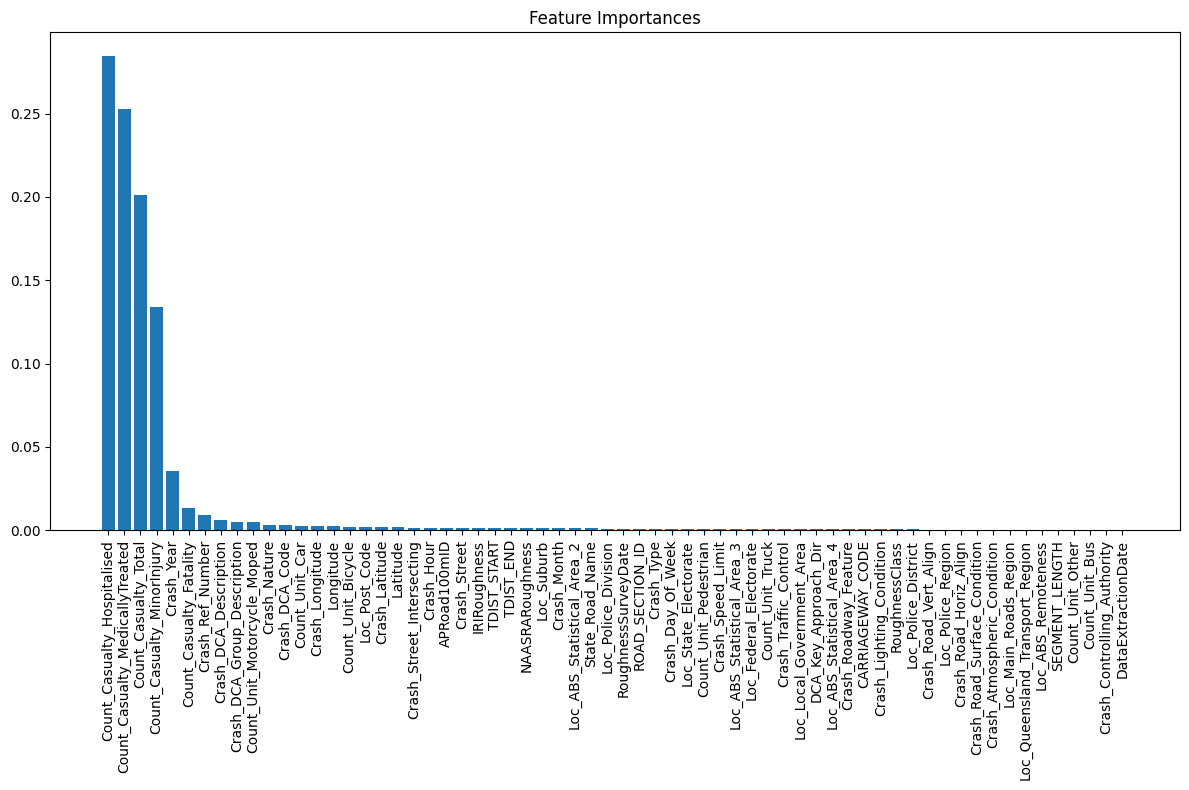

Accuracy after Feature Selection: 0.9995


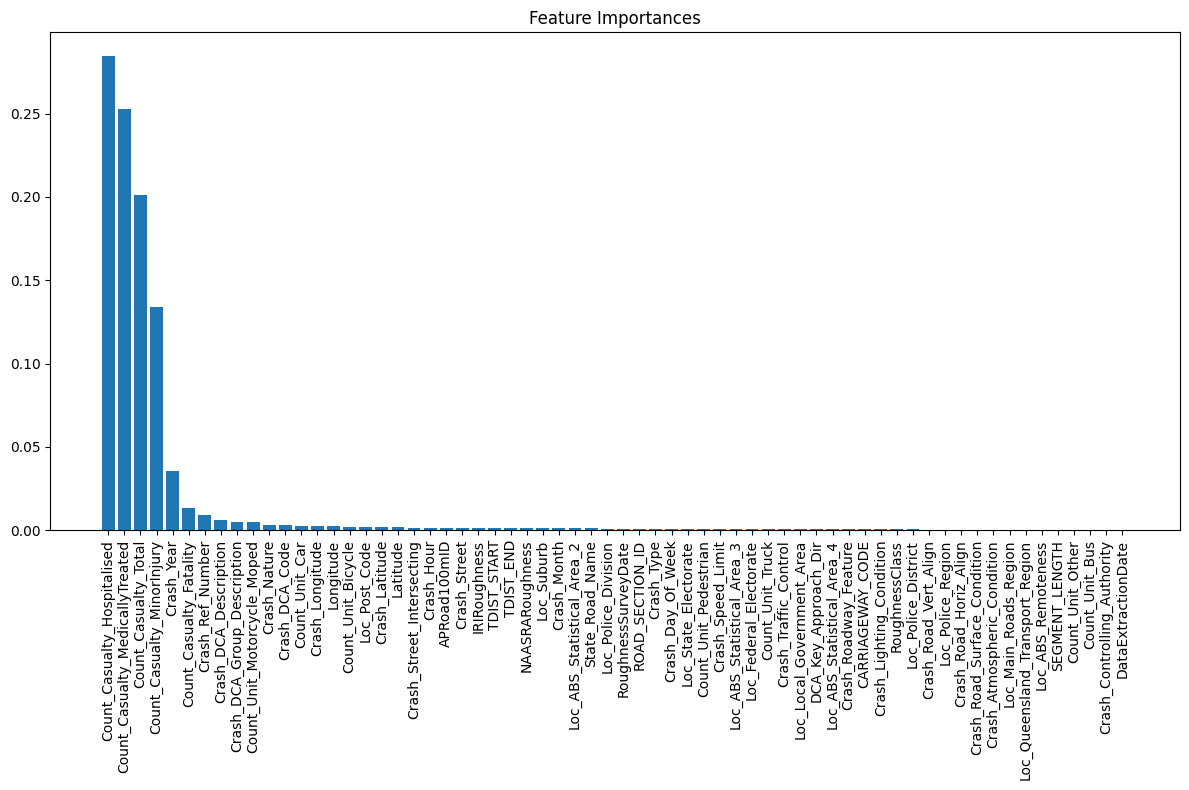

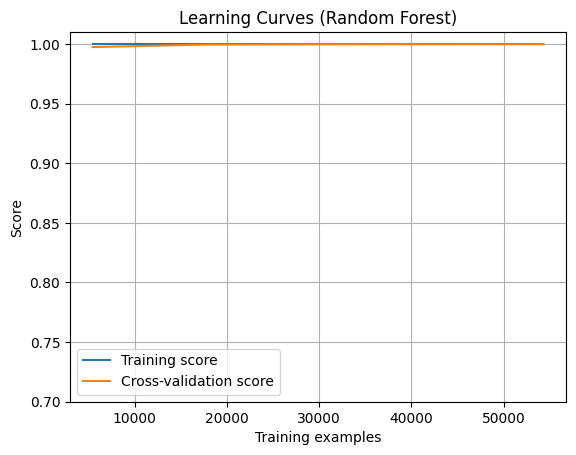

In [ ]:


X = df_cd.drop('Crash_Severity', axis=1)  
y = df_cd['Crash_Severity']  

# splite train set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# train the inititalize modelling
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# evlauation
y_pred = model.predict(X_test)
initial_accuracy = accuracy_score(y_test, y_pred)
print(f"Initial Accuracy: {initial_accuracy:.4f}")

# extract the important feature
importances = model.feature_importances_
features = X.columns
sorted_indices = importances.argsort()[::-1]

# visulization
plt.figure(figsize=(12, 8))
plt.title('Feature Importances')
plt.bar(range(X.shape[1]), importances[sorted_indices], align='center')
plt.xticks(range(X.shape[1]), [features[i] for i in sorted_indices], rotation=90)
plt.tight_layout()
plt.show()

# choose most impotrant feature
importance_threshold = 0.05
important_indices = importances > importance_threshold
important_features1 = features[important_indices]

# retrain modelling
X_train_important = X_train[important_features1]
X_test_important = X_test[important_features1]

model_important = RandomForestClassifier(n_estimators=100, random_state=42,max_depth=10)
model_important.fit(X_train_important, y_train)

# evaluation
y_pred_important = model_important.predict(X_test_important)
important_accuracy = accuracy_score(y_test, y_pred_important)
print(f"Accuracy after Feature Selection: {important_accuracy:.4f}")
importances = model.feature_importances_
features = X.columns
sorted_indices = importances.argsort()[::-1]

# visulization
plt.figure(figsize=(12, 8))
plt.title('Feature Importances')
plt.bar(range(X.shape[1]), importances[sorted_indices], align='center')
plt.xticks(range(X.shape[1]), [features[i] for i in sorted_indices], rotation=90)
plt.tight_layout()
plt.show()
title = "Learning Curves (Random Forest)"
cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=0)
plot_learning_curve(model, title, X, y, ylim=(0.7, 1.01), cv=cv, n_jobs=4)
plt.show()

In [28]:
cd_feature=["NAASRARoughness", "IRIRoughness" , "Count_Casualty_MedicallyTreated", "Count_Casualty_Hospitalised"]
df_cd_afs=df_cd[cd_feature]
print(df_cd_afs)

        NAASRARoughness  IRIRoughness  Count_Casualty_MedicallyTreated  \
8                    41          1.60                                0   
10                  114          4.34                                0   
12                   41          1.61                                0   
13                  114          4.34                                1   
14                   41          1.58                                0   
...                 ...           ...                              ...   
293721               82          3.13                                0   
293723               67          2.64                                0   
293725               50          1.93                                1   
293729               86          3.29                                0   
293730               43          1.69                                1   

        Count_Casualty_Hospitalised  
8                                 0  
10                                0

Number of duplicate rows: 0
Count_Casualty_Hospitalised: 0.284
Count_Casualty_MedicallyTreated: 0.238
Count_Casualty_All: 0.177
Count_Casualty_Fatality: 0.141
Count_Casualty_MinorInjury: 0.125
Count_Crashes: 0.021
Involving_Unlicensed_Driver: 0.003
Involving_Overseas_Licensed_Driver: 0.003
Involving_Senior_Driver_60plus: 0.002
Involving_Young_Driver_16-24: 0.002
Involving_Provisional_Driver: 0.001
Involving_Female_Driver: 0.001
Involving_Male_Driver: 0.001


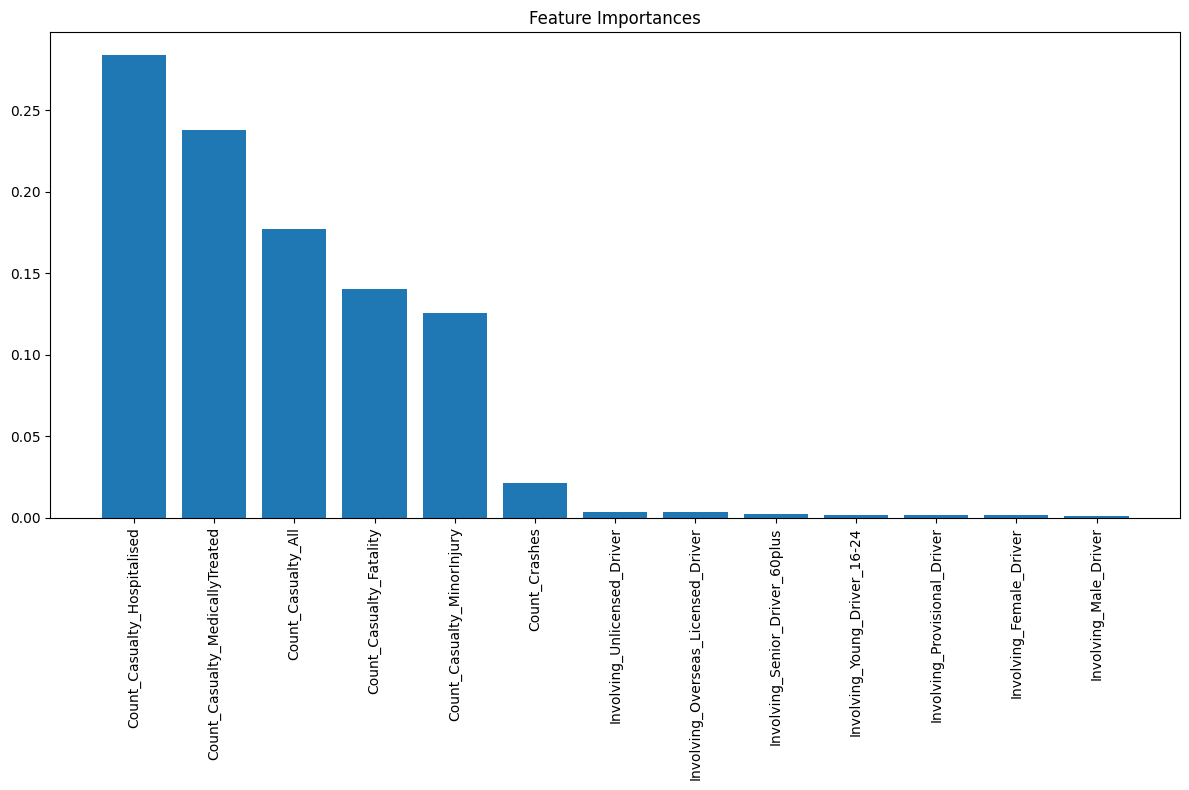

In [29]:
#driver involvement
df=df_DI
# DATA CLEAN
df.dropna(inplace=True)
duplicates = df.duplicated()
print("Number of duplicate rows:", duplicates.sum())
if duplicates.sum() > 0:
    print(df[duplicates])

# Crash Year and Crash polic region not relevant
data = df.drop(['Crash_Year','Crash_Police_Region'], axis=1)

# dataprocess
# all leabe encoding
label_encoders = {}
for column in data.columns:
      if column not in columns_not_to_encode:
          if data[column].dtype == object:
              le = LabelEncoder()
              data[column] = le.fit_transform(data[column])
              label_encoders[column] = le
         
#just encode the Crash everity    
# column_to_encode = 'Crash_Severity'
# data[column_to_encode] = le.fit_transform(data[column_to_encode])
# label_encoders = {column_to_encode: le}
             
X = data.drop('Crash_Severity', axis=1)  # based on the crash Sverity
y = data['Crash_Severity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
importances = model.feature_importances_
features = X.columns
sorted_indices = importances.argsort()[::-1]
for index in sorted_indices:
    print(f"{features[index]}: {importances[index]:.3f}")#print 
plt.figure(figsize=(12, 8))
plt.title('Feature Importances')
plt.bar(range(X.shape[1]), importances[sorted_indices], align='center')
plt.xticks(range(X.shape[1]), [features[i] for i in sorted_indices], rotation=90)
plt.tight_layout()
plt.show()


Initial Accuracy: 1.0000


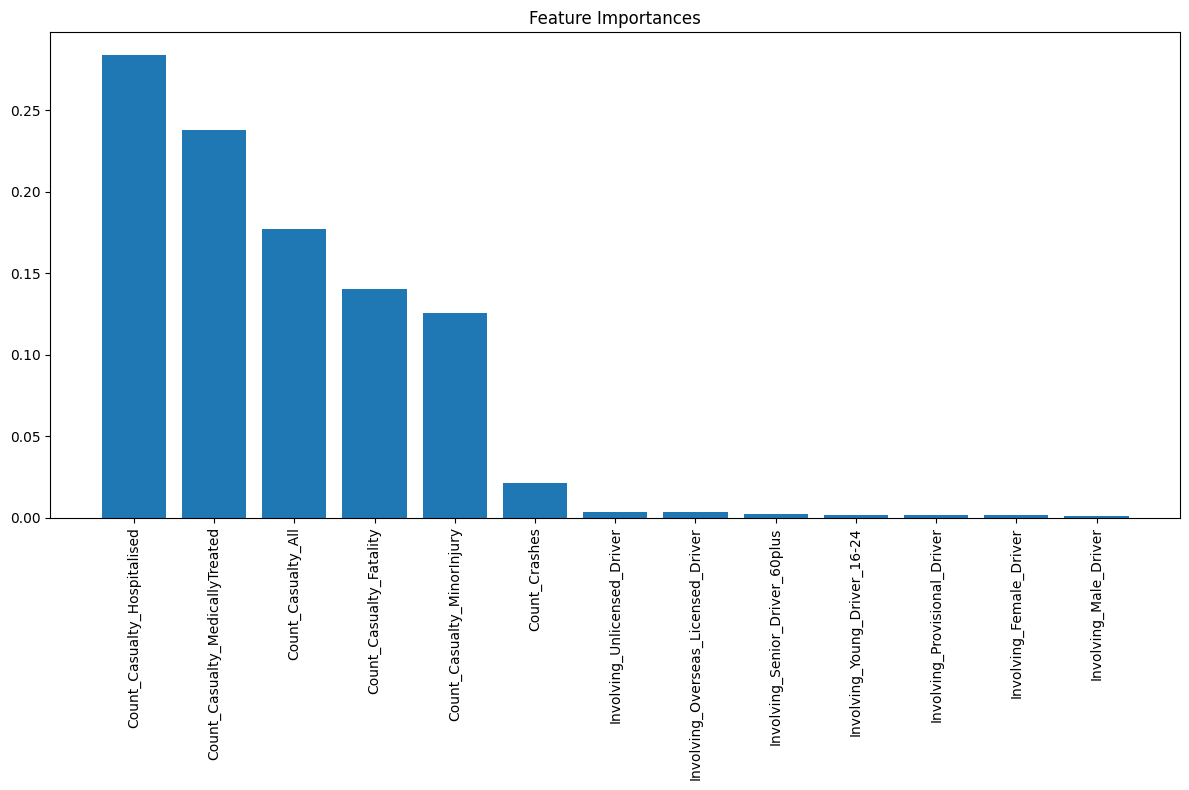

Accuracy after Feature Selection: 1.0000


In [ ]:

X = data.drop('Crash_Severity', axis=1)  
y = data['Crash_Severity']  

# split the data 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# train the Random forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# evaluate the initial modelling
y_pred = model.predict(X_test)
initial_accuracy = accuracy_score(y_test, y_pred)
print(f"Initial Accuracy: {initial_accuracy:.4f}")

# extract feature importance
importances = model.feature_importances_
features = X.columns
sorted_indices = importances.argsort()[::-1]

# visualisation
plt.figure(figsize=(12, 8))
plt.title('Feature Importances')
plt.bar(range(X.shape[1]), importances[sorted_indices], align='center')
plt.xticks(range(X.shape[1]), [features[i] for i in sorted_indices], rotation=90)
plt.tight_layout()
plt.show()

# select the important one
importance_threshold = 0.01
important_indices = importances > importance_threshold
important_features = features[important_indices]

# use important feature re-train
X_train_important = X_train[important_features]
X_test_important = X_test[important_features]

model_important = RandomForestClassifier(n_estimators=100, random_state=42)
model_important.fit(X_train_important, y_train)

# evaluation
y_pred_important = model_important.predict(X_test_important)
important_accuracy = accuracy_score(y_test, y_pred_important)
print(f"Accuracy after Feature Selection: {important_accuracy:.4f}")

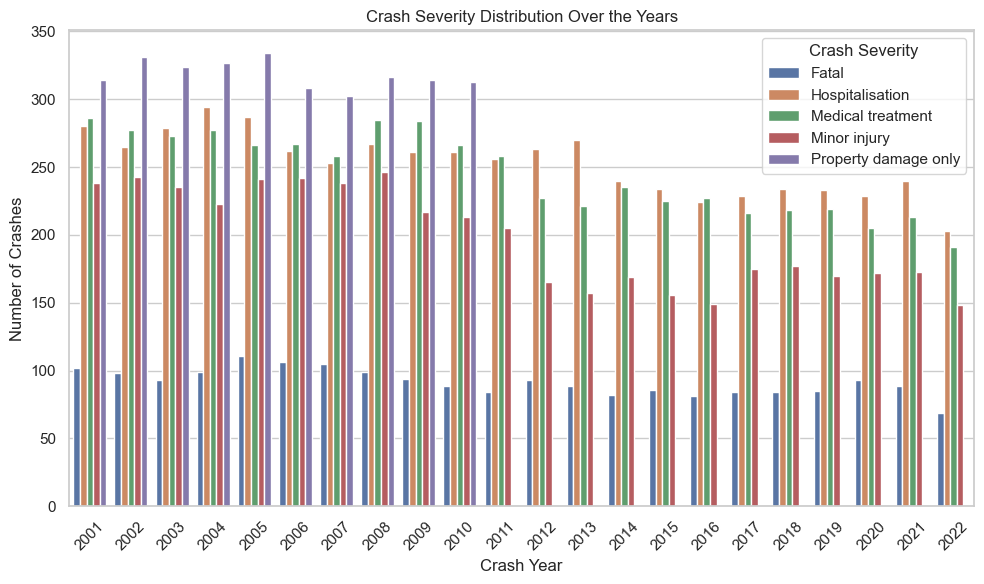

In [ ]:
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.countplot(data=df_DI, x='Crash_Year', hue='Crash_Severity')
plt.title('Crash Severity Distribution Over the Years')
plt.xlabel('Crash Year')
plt.ylabel('Number of Crashes')
plt.xticks(rotation=45)
plt.legend(title='Crash Severity')
plt.tight_layout()
plt.show()


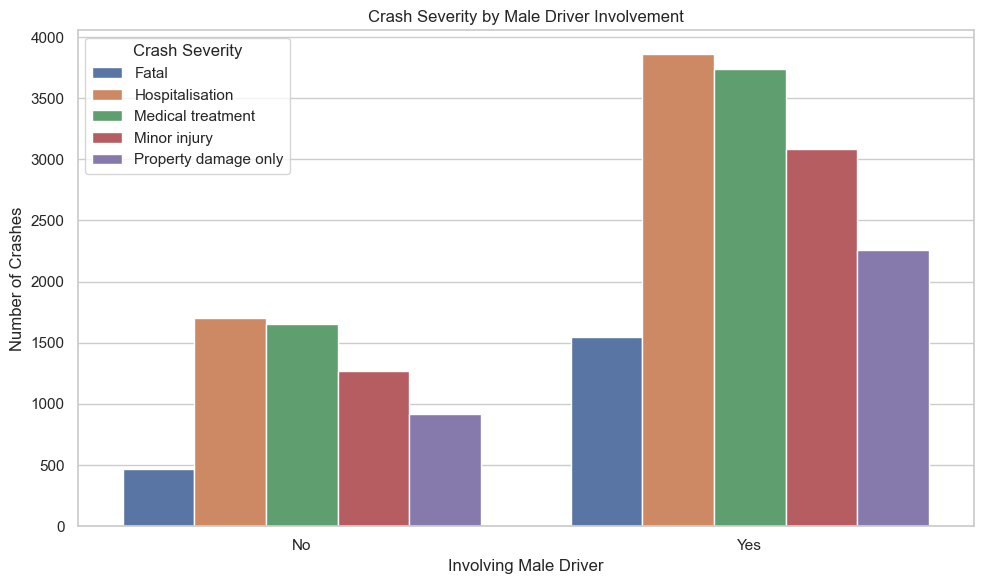

In [32]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_DI, x='Involving_Male_Driver', hue='Crash_Severity')
plt.title('Crash Severity by Male Driver Involvement')
plt.xlabel('Involving Male Driver')
plt.ylabel('Number of Crashes')
plt.legend(title='Crash Severity')
plt.tight_layout()
plt.show()

In [ ]:
df_DI_afs=df_DI[["Count_Casualty_Hospitalised","Count_Casualty_MedicallyTreated", "Count_Casualty_All"]]

Number of duplicate rows: 0
Casualty_Count: 0.356
Casualty_AgeGroup: 0.242
Crash_PoliceRegion: 0.233
Casualty_Restraint_Helmet_Use: 0.106
Casualty_Gender: 0.040
Casualty_Road_User_Type: 0.023


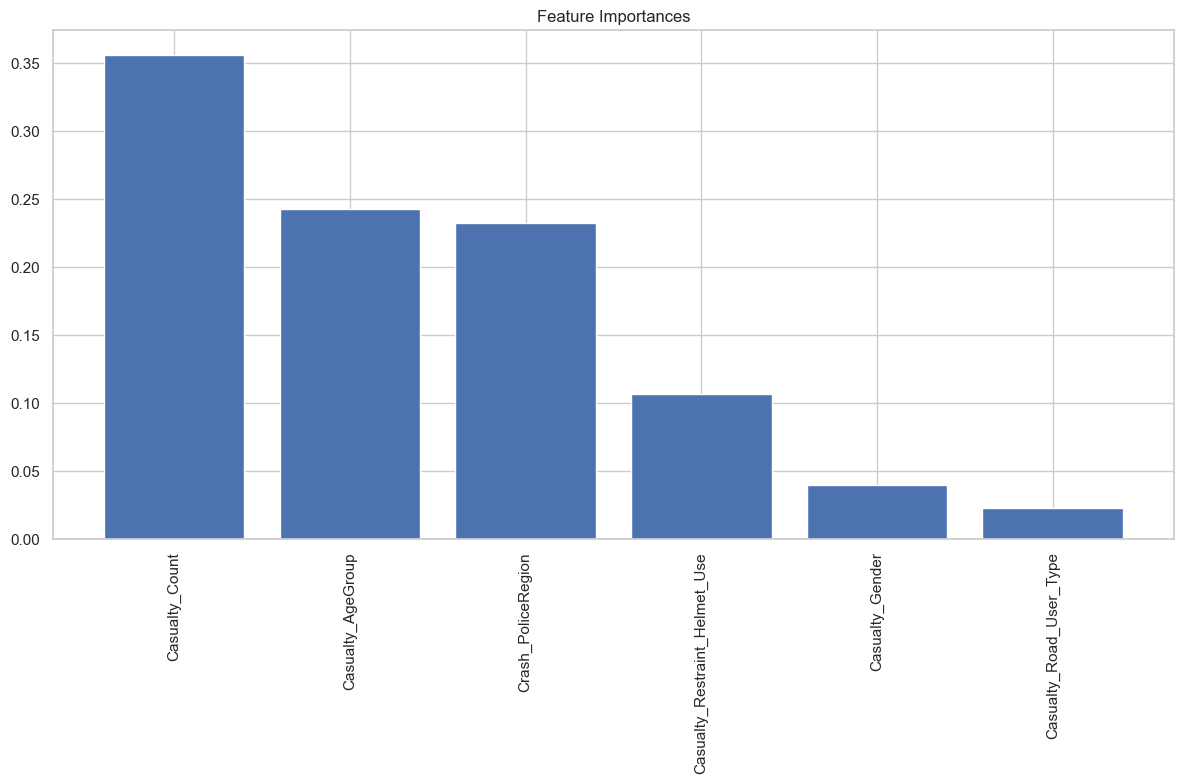

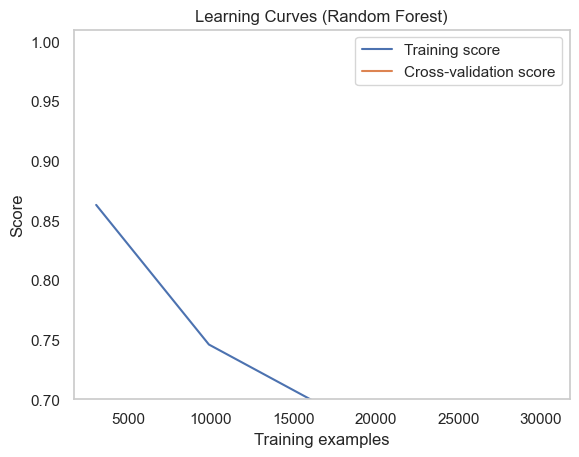

In [33]:
df=df_HU
#data clean
df.dropna(inplace=True)
duplicates = df.duplicated()
print("Number of duplicate rows:", duplicates.sum())
if duplicates.sum() > 0:
    print(df[duplicates])
# crash year is the first one, need check
data = df.drop(['Crash_Year'],axis=1)
label_encoders = {}
for column in data.columns:
    if data[column].dtype == object:
        le = LabelEncoder()
        data[column] = le.fit_transform(data[column])
        label_encoders[column] = le
X = data.drop('Casualty_Severity', axis=1)  # based on the Casualty_Severity
y = data['Casualty_Severity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
importances = model.feature_importances_
features = X.columns
sorted_indices = importances.argsort()[::-1]
for index in sorted_indices:
    print(f"{features[index]}: {importances[index]:.3f}")#print
plt.figure(figsize=(12, 8))
plt.title('Feature Importances')
plt.bar(range(X.shape[1]), importances[sorted_indices], align='center')
plt.xticks(range(X.shape[1]), [features[i] for i in sorted_indices], rotation=90)
plt.tight_layout()
plt.show()
#learning Curves check(after delete crash_year columnns)
title = "Learning Curves (Random Forest)"
cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=0)
plot_learning_curve(model, title, X, y, ylim=(0.7, 1.01), cv=cv, n_jobs=4)
plt.show()

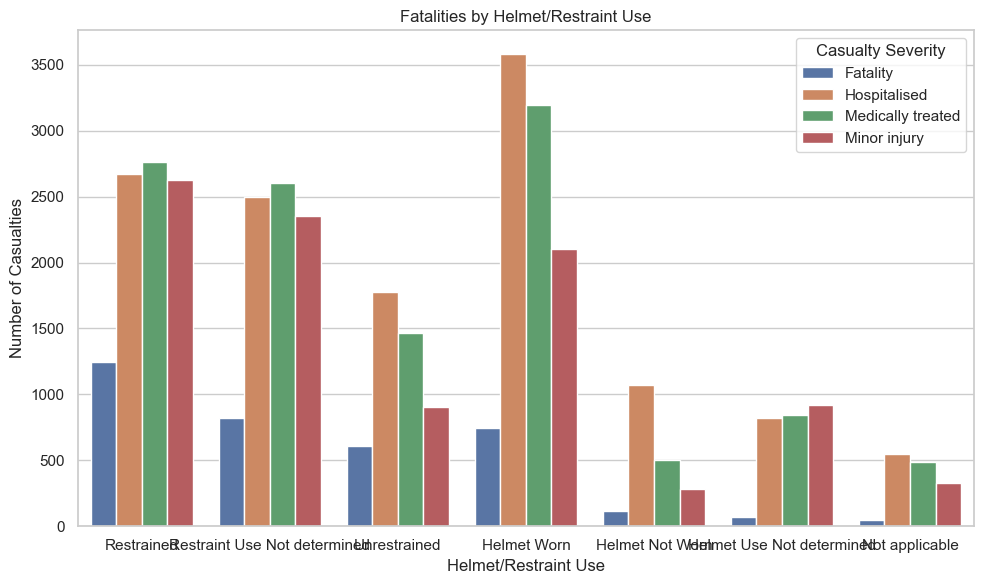

In [34]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_HU, x='Casualty_Restraint_Helmet_Use', hue='Casualty_Severity')
plt.title('Fatalities by Helmet/Restraint Use')
plt.xlabel('Helmet/Restraint Use')
plt.ylabel('Number of Casualties')
plt.legend(title='Casualty Severity')
plt.tight_layout()
plt.show()

Number of duplicate rows: 0
Casualty_Count: 0.372
Casualty_AgeGroup: 0.237
Crash_Police_Region: 0.231
Casualty_RoadUserType: 0.127
Casualty_Gender: 0.033


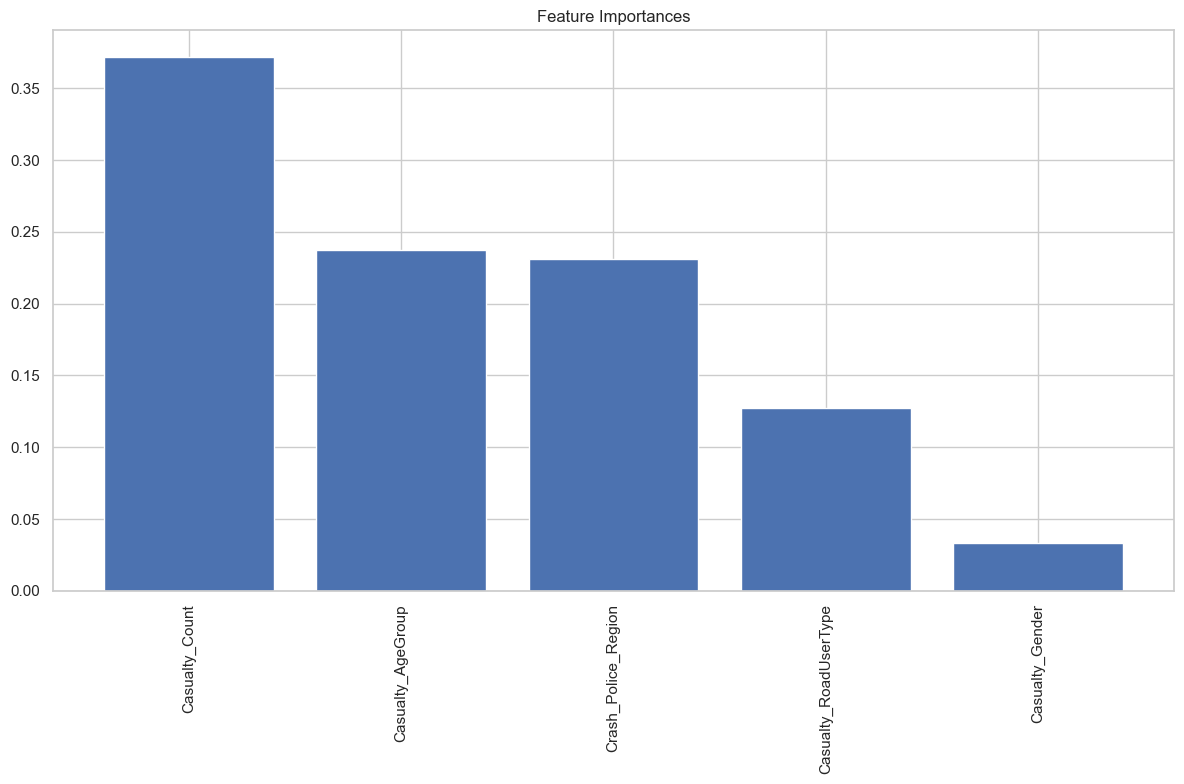

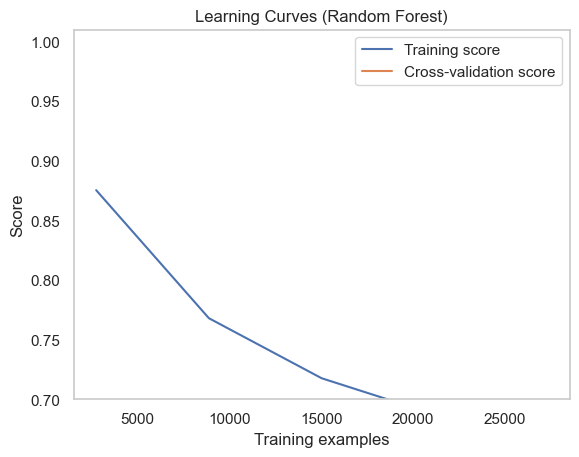

In [35]:
df=df_RC
#data clean
df.dropna(inplace=True)
duplicates = df.duplicated()
print("Number of duplicate rows:", duplicates.sum())
if duplicates.sum() > 0:
    print(df[duplicates])
# drop Crash_Year
data = df.drop(['Crash_Year'],axis=1)
#data processing(encoding all)
label_encoders = {}
for column in data.columns:
    if data[column].dtype == object:
        le = LabelEncoder()
        data[column] = le.fit_transform(data[column])
        label_encoders[column] = le
X = data.drop('Casualty_Severity', axis=1)  # assume Casualty_Severity
y = data['Casualty_Severity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
importances = model.feature_importances_
features = X.columns
sorted_indices = importances.argsort()[::-1]#print
for index in sorted_indices:
    print(f"{features[index]}: {importances[index]:.3f}")
plt.figure(figsize=(12, 8))
plt.title('Feature Importances')
plt.bar(range(X.shape[1]), importances[sorted_indices], align='center')
plt.xticks(range(X.shape[1]), [features[i] for i in sorted_indices], rotation=90)
plt.tight_layout()
plt.show()
#use learning Curves check(after delete crash year)
title = "Learning Curves (Random Forest)"
cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=0)
plot_learning_curve(model, title, X, y, ylim=(0.7, 1.01), cv=cv, n_jobs=4)
plt.show()
df_RC=data

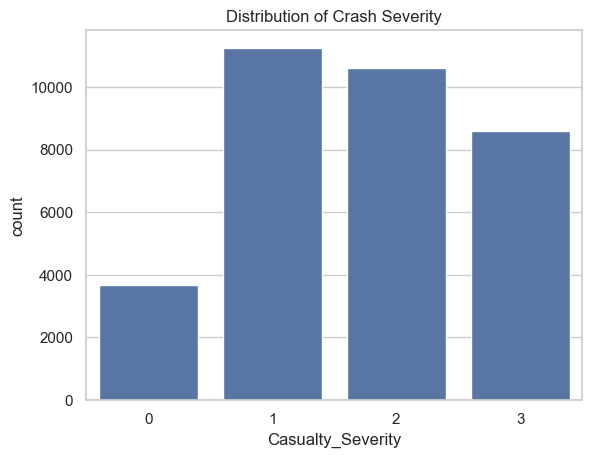

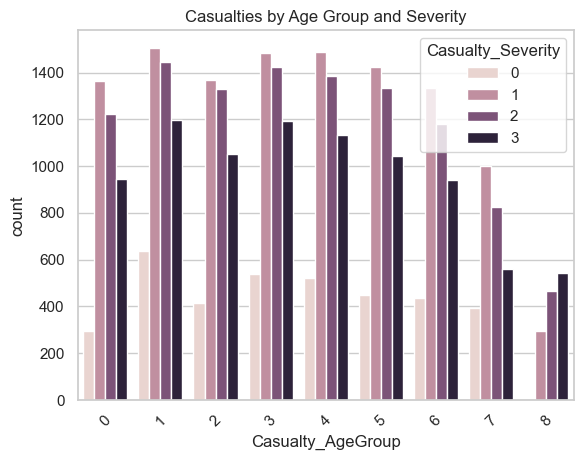

In [36]:
sns.countplot(data=df_RC, x='Casualty_Severity')
plt.title('Distribution of Crash Severity')
plt.show()
sns.countplot(data=df_RC, x='Casualty_AgeGroup', hue='Casualty_Severity')
plt.title('Casualties by Age Group and Severity')
plt.xticks(rotation=45)
plt.show()
numeric_df = df_RC.select_dtypes(include=['float64', 'int64'])


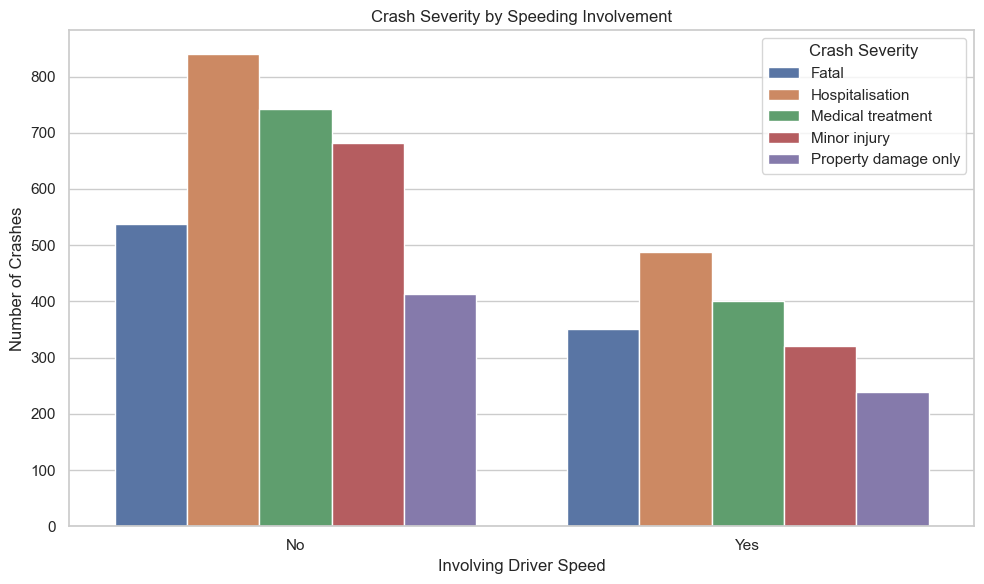

In [37]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_FIRC, x='Involving_Driver_Speed', hue='Crash_Severity')
plt.title('Crash Severity by Speeding Involvement')
plt.xlabel('Involving Driver Speed')
plt.ylabel('Number of Crashes')
plt.legend(title='Crash Severity')
plt.tight_layout()
plt.show()


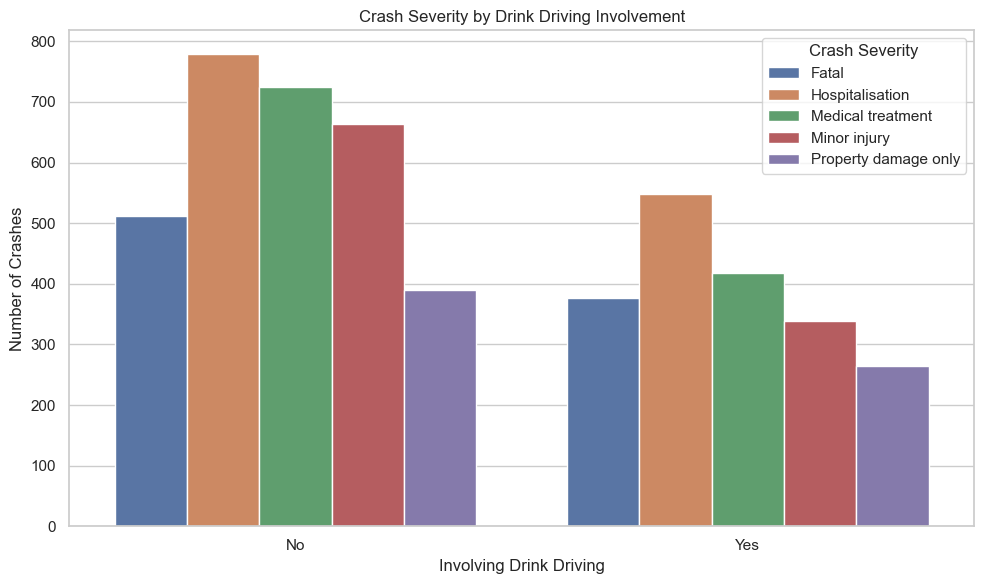

In [38]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_FIRC, x='Involving_Drink_Driving', hue='Crash_Severity')
plt.title('Crash Severity by Drink Driving Involvement')
plt.xlabel('Involving Drink Driving')
plt.ylabel('Number of Crashes')
plt.legend(title='Crash Severity')
plt.tight_layout()
plt.show()

Number of duplicate rows: 0
Count_Hospitalised: 0.268
Count_Fatality: 0.213
Count_Medically_Treated: 0.190
Count_All_Casualties: 0.156
Count_Minor_Injury: 0.110
Count_Crashes: 0.028
Crash_Year: 0.017
Involving_Defective_Vehicle: 0.005
Crash_Police_Region: 0.003
Involving_Fatigued_Driver: 0.003
Involving_Drink_Driving: 0.003
Involving_Driver_Speed: 0.003


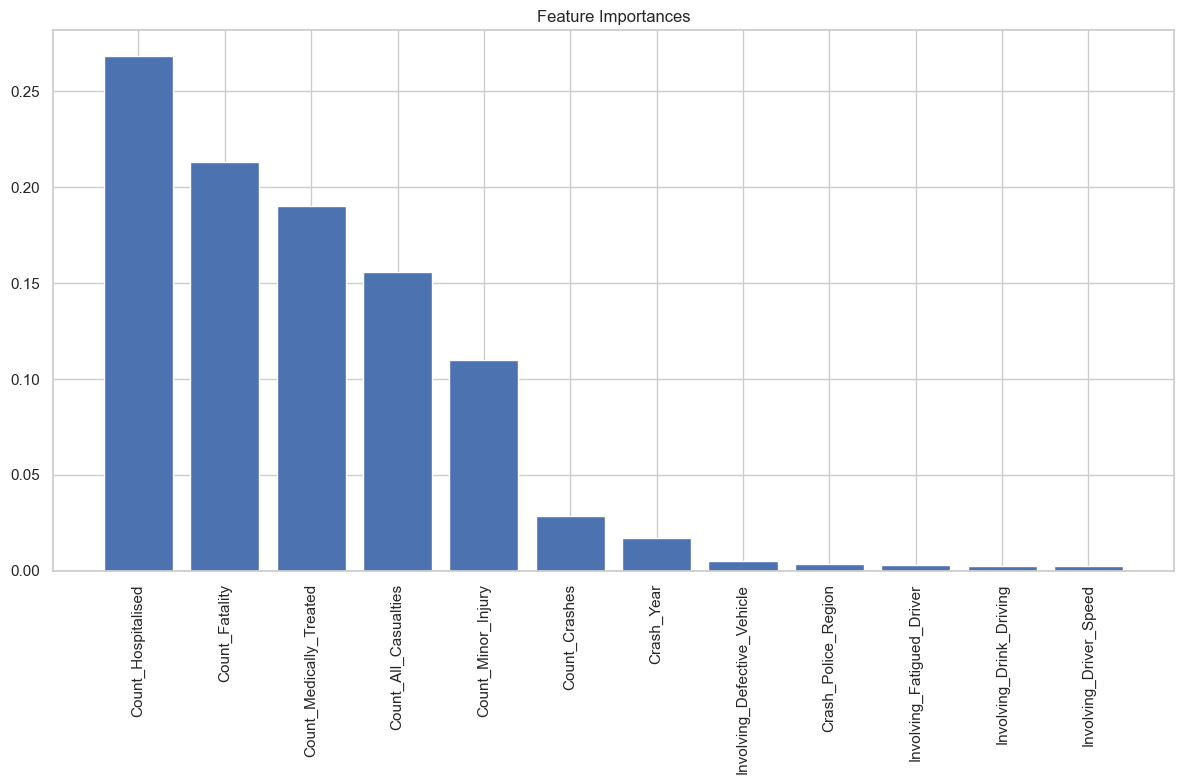

In [39]:
df=df_FIRC
#Data clean
df.dropna(inplace=True)
duplicates = df.duplicated()
print("Number of duplicate rows:", duplicates.sum())
if duplicates.sum() > 0:
    print(df[duplicates])

data = df

#data processing 
# all encode
label_encoders = {}
for column in data.columns:
    if data[column].dtype == object:
        le = LabelEncoder()
        data[column] = le.fit_transform(data[column])
        label_encoders[column] = le
X = data.drop('Crash_Severity', axis=1)  # assume Crash_severity
y = data['Crash_Severity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
importances = model.feature_importances_
features = X.columns
sorted_indices = importances.argsort()[::-1]
for index in sorted_indices:#print
    print(f"{features[index]}: {importances[index]:.3f}")
plt.figure(figsize=(12, 8))
plt.title('Feature Importances')
plt.bar(range(X.shape[1]), importances[sorted_indices], align='center')
plt.xticks(range(X.shape[1]), [features[i] for i in sorted_indices], rotation=90)
plt.tight_layout()
plt.show()

In [40]:
print(df_cd[important_features2].columns)
print(df_cd['Crash_Severity'].value_counts())

Index(['Crash_Year', 'Count_Casualty_Hospitalised',
       'Count_Casualty_MedicallyTreated', 'Count_Casualty_MinorInjury',
       'Count_Casualty_Total', 'NAASRARoughness', 'IRIRoughness',
       'RoughnessSurveyDate'],
      dtype='object')
Crash_Severity
2    22498
1    18850
4    15970
3     9970
0      613
Name: count, dtype: int64


In [ ]:
data = df_cd

X = data[['Count_Casualty_Hospitalised', 'Count_Casualty_MedicallyTreated','Count_Casualty_MinorInjury', 'Count_Casualty_Total']]
y = data['Crash_Severity']
# standlization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)


# modeling and evaluation
model = SVC(random_state=41)
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf','poly','linear']
}
grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)
print(f"Best parameters found: {grid.best_params_}")
print(f"Best cross-validation score: {grid.best_score_:.3f}")

best_m = grid.best_estimator_
best_m.fit(X_train, y_train)
# cross violation
cv_scores = cross_val_score(best_m, X_scaled, y, cv=5)
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean cross-validation score: {cv_scores.mean():.3f}")
y_pred = best_m.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))


Best parameters found: {'C': 0.1, 'gamma': 1, 'kernel': 'linear'}
Best cross-validation score: 1.000
Cross-validation scores: [1.         1.         1.         1.         0.99985272]
Mean cross-validation score: 1.000
Accuracy: 1.000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       182
           1       1.00      1.00      1.00      5657
           2       1.00      1.00      1.00      6671
           3       1.00      1.00      1.00      2950
           4       1.00      1.00      1.00      4911

    accuracy                           1.00     20371
   macro avg       1.00      1.00      1.00     20371
weighted avg       1.00      1.00      1.00     20371



In [ ]:

data = df_cd

X = df_cd[['NAASRARoughness', 'IRIRoughness','Crash_Year','Crash_Hour','Crash_Month','Crash_Hour','Crash_Day_Of_Week','Crash_Street_Intersecting','Crash_Street']]
y = data['Crash_Severity']
# standlization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)


# modeling and evaluation
model = SVC(random_state=41)
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}
grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)
print(f"Best parameters found: {grid.best_params_}")
print(f"Best cross-validation score: {grid.best_score_:.3f}")

best_m = grid.best_estimator_
best_m.fit(X_train, y_train)
# cross violation
cv_scores = cross_val_score(best_m, X_scaled, y, cv=5)
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean cross-validation score: {cv_scores.mean():.3f}")
y_pred = best_m.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Best parameters found: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best cross-validation score: 0.404
Cross-validation scores: [0.36212355 0.37540501 0.3622975  0.37665685 0.50198822]
Mean cross-validation score: 0.396
Accuracy: 0.413
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       182
           1       0.47      0.06      0.11      5657
           2       0.43      0.54      0.48      6671
           3       0.00      0.00      0.00      2950
           4       0.40      0.91      0.55      4911

    accuracy                           0.41     20371
   macro avg       0.26      0.30      0.23     20371
weighted avg       0.37      0.41      0.32     20371



C:\Users\29084\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\29084\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\29084\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classificati

In [ ]:
# initialize SMOTE
smote = SMOTE(random_state=42)

# undersample dataset
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
# retrain modelling
model.fit(X_resampled, y_resampled)
# use test set predict
y_pred_smote= model.predict(X_test)
# evluation
from sklearn.metrics import accuracy_score, classification_report
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.334
Classification Report:
              precision    recall  f1-score   support

           0       0.01      0.18      0.02       182
           1       0.41      0.25      0.32      5657
           2       0.46      0.16      0.24      6671
           3       0.13      0.01      0.02      2950
           4       0.40      0.86      0.54      4911

    accuracy                           0.33     20371
   macro avg       0.28      0.29      0.23     20371
weighted avg       0.38      0.33      0.30     20371



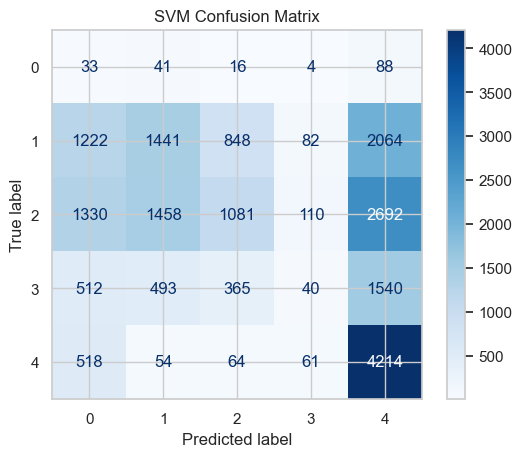

In [ ]:
# generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# draw confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_m.classes_)
disp.plot(cmap=plt.cm.Blues)

# add title and graphic
plt.title('SVM Confusion Matrix')
plt.show()

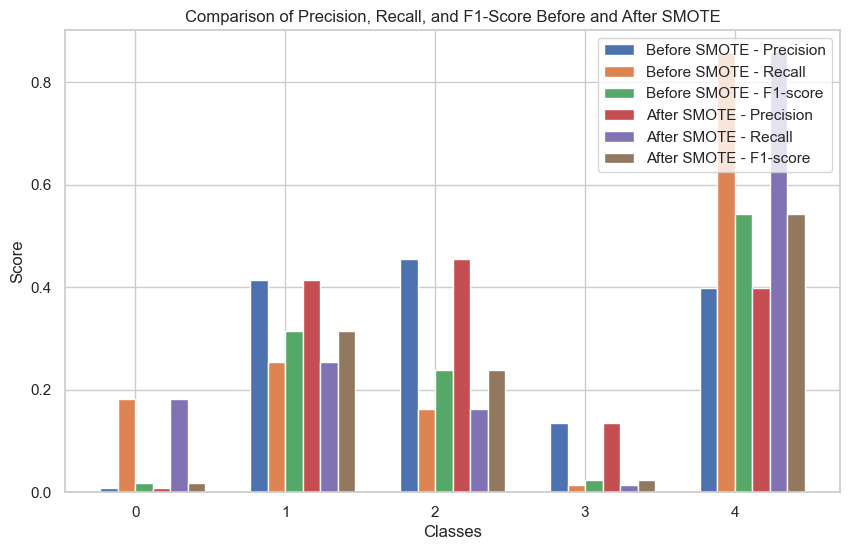

In [51]:
# transfer to dataframe
def get_classification_report_df(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    return pd.DataFrame(report).transpose()

# get Report from before SMOTE or after SMOTE
report_no_smote = get_classification_report_df(y_test, y_pred)
report_smote = get_classification_report_df(y_test, y_pred_smote)

# draw precision, recall,f1 score compare diagram
metrics = ['precision', 'recall', 'f1-score']
labels = report_no_smote.index[:-3]  

x = np.arange(len(labels))  
width = 0.35 

fig, ax = plt.subplots(figsize=(10, 6))

# draw the diagram before SMOTE
for i, metric in enumerate(metrics):
    ax.bar(x - width/2 + i*width/3, report_no_smote[metric][:-3], width/3, label=f'Before SMOTE - {metric.capitalize()}')

# after SMOTE
for i, metric in enumerate(metrics):
    ax.bar(x + width/2 + i*width/3, report_smote[metric][:-3], width/3, label=f'After SMOTE - {metric.capitalize()}')

#draw the diagram
ax.set_xlabel('Classes')
ax.set_ylabel('Score')
ax.set_title('Comparison of Precision, Recall, and F1-Score Before and After SMOTE')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(loc='upper right')

plt.show()


C:\Users\29084\AppData\Local\Temp\ipykernel_6368\1934624227.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  report_no_smote.loc['accuracy'][0],
C:\Users\29084\AppData\Local\Temp\ipykernel_6368\1934624227.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  report_smote.loc['accuracy'][0],


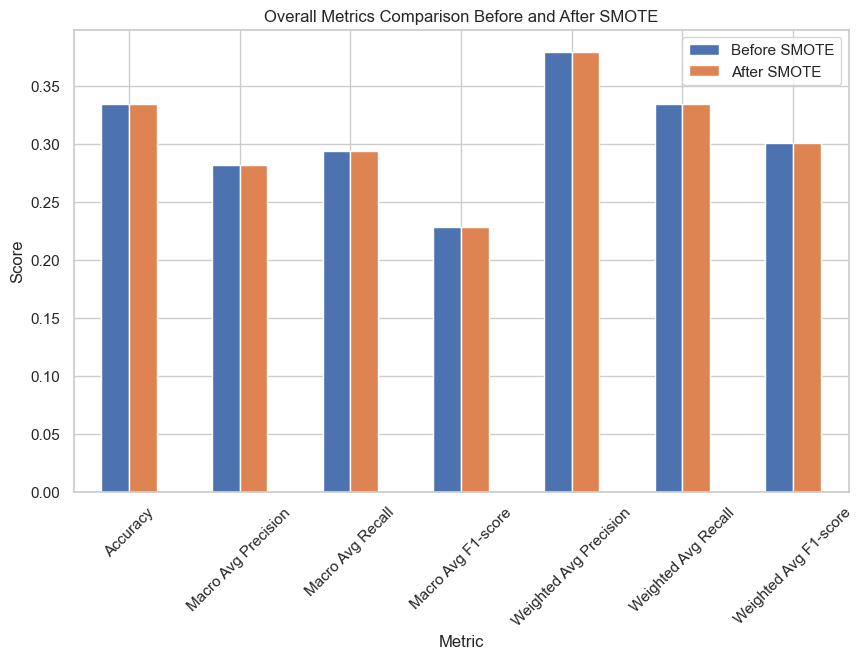

In [52]:
# compare
overall_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Macro Avg Precision', 'Macro Avg Recall', 'Macro Avg F1-score', 'Weighted Avg Precision', 'Weighted Avg Recall', 'Weighted Avg F1-score'],
    'Before SMOTE': [
        report_no_smote.loc['accuracy'][0],
        report_no_smote.loc['macro avg']['precision'],
        report_no_smote.loc['macro avg']['recall'],
        report_no_smote.loc['macro avg']['f1-score'],
        report_no_smote.loc['weighted avg']['precision'],
        report_no_smote.loc['weighted avg']['recall'],
        report_no_smote.loc['weighted avg']['f1-score']
    ],
    'After SMOTE': [
        report_smote.loc['accuracy'][0],
        report_smote.loc['macro avg']['precision'],
        report_smote.loc['macro avg']['recall'],
        report_smote.loc['macro avg']['f1-score'],
        report_smote.loc['weighted avg']['precision'],
        report_smote.loc['weighted avg']['recall'],
        report_smote.loc['weighted avg']['f1-score']
    ]
})

# DRAW Diagram
overall_metrics.set_index('Metric').plot(kind='bar', figsize=(10, 6))
plt.ylabel('Score')
plt.title('Overall Metrics Comparison Before and After SMOTE')
plt.xticks(rotation=45)
plt.show()


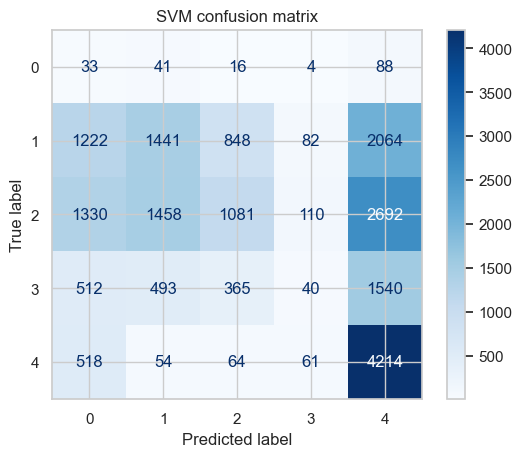

In [53]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_m.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.title('SVM confusion matrix')
plt.show()

In [ ]:
data = df_cd

# Label Encoding and data stanlization
label_cols = ['Count_Casualty_Hospitalised', 'Count_Casualty_MedicallyTreated','NAASRARoughness', 'IRIRoughness']
le = LabelEncoder()

#Label Encoding
for col in label_cols:
    data[col] = le.fit_transform(data[col])

# extract feature（X）and target variable（y）
X = data[['Crash_Year', 'NAASRARoughness',
       'IRIRoughness']]
y = data['Crash_Severity']

# data standlization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# split dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


In [ ]:

# create DNN modelling
model = Sequential()

# add lyer
model.add(Dense(128, input_dim=X_train_resampled.shape[1], activation='relu'))
model.add(Dropout(0.2))  # Dropout reduce overfitting
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))

# output
model.add(Dense(5, activation='softmax'))

# pragram modelling
optimizer = Adam(learning_rate=0.001)
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# training model
model.fit(X_train_resampled, y_train_resampled, epochs=50, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/50


C:\Users\29084\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2473/2473 ━━━━━━━━━━━━━━━━━━━━ 3s 755us/step - accuracy: 0.2950 - loss: 1.5160 - val_accuracy: 0.3477 - val_loss: 1.4589
Epoch 2/50
2473/2473 ━━━━━━━━━━━━━━━━━━━━ 2s 702us/step - accuracy: 0.3131 - loss: 1.4859 - val_accuracy: 0.4063 - val_loss: 1.4467
Epoch 3/50
2473/2473 ━━━━━━━━━━━━━━━━━━━━ 2s 705us/step - accuracy: 0.3156 - loss: 1.4831 - val_accuracy: 0.3602 - val_loss: 1.4499
Epoch 4/50
2473/2473 ━━━━━━━━━━━━━━━━━━━━ 2s 700us/step - accuracy: 0.3150 - loss: 1.4812 - val_accuracy: 0.3811 - val_loss: 1.4578
Epoch 5/50
2473/2473 ━━━━━━━━━━━━━━━━━━━━ 2s 712us/step - accuracy: 0.3164 - loss: 1.4789 - val_accuracy: 0.4017 - val_loss: 1.4429
Epoch 6/50
2473/2473 ━━━━━━━━━━━━━━━━━━━━ 2s 695us/step - accuracy: 0.3180 - loss: 1.4777 - val_accuracy: 0.3545 - val_loss: 1.4629
Epoch 7/50
2473/2473 ━━━━━━━━━━━━━━━━━━━━ 2s 703us/step - accuracy: 0.3185 - loss: 1.4774 - val_accuracy: 0.3858 - val_loss: 1.4395
Epoch 8/50
2473/2473 ━━━━━━━━━━━━━━━━━━━━ 2s 704us/step - accuracy: 0.3206 - loss: 1.47

In [ ]:

model = Sequential()
model.add(Dense(256, input_dim=X_train.shape[1], activation='relu')) 
model.add(Dropout(0.2))
model.add(Dense(128, activation='relu'))  
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(5, activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {accuracy:.3f}")


637/637 ━━━━━━━━━━━━━━━━━━━━ 0s 501us/step - accuracy: 0.1012 - loss: 1.6165
Test accuracy: 0.102


In [ ]:
print(df_cd.columns)

Index(['Crash_Ref_Number', 'Crash_Severity', 'Crash_Year', 'Crash_Month',
       'Crash_Day_Of_Week', 'Crash_Hour', 'Crash_Nature', 'Crash_Type',
       'Crash_Longitude', 'Crash_Latitude', 'Crash_Street',
       'Crash_Street_Intersecting', 'State_Road_Name', 'Loc_Suburb',
       'Loc_Local_Government_Area', 'Loc_Post_Code', 'Loc_Police_Division',
       'Loc_Police_District', 'Loc_Police_Region',
       'Loc_Queensland_Transport_Region', 'Loc_Main_Roads_Region',
       'Loc_ABS_Statistical_Area_2', 'Loc_ABS_Statistical_Area_3',
       'Loc_ABS_Statistical_Area_4', 'Loc_ABS_Remoteness',
       'Loc_State_Electorate', 'Loc_Federal_Electorate',
       'Crash_Controlling_Authority', 'Crash_Roadway_Feature',
       'Crash_Traffic_Control', 'Crash_Speed_Limit',
       'Crash_Road_Surface_Condition', 'Crash_Atmospheric_Condition',
       'Crash_Lighting_Condition', 'Crash_Road_Horiz_Align',
       'Crash_Road_Vert_Align', 'Crash_DCA_Code', 'Crash_DCA_Description',
       'Crash_DCA_Group_De

Number of clusters: 8
Silhouette Score: 0.600


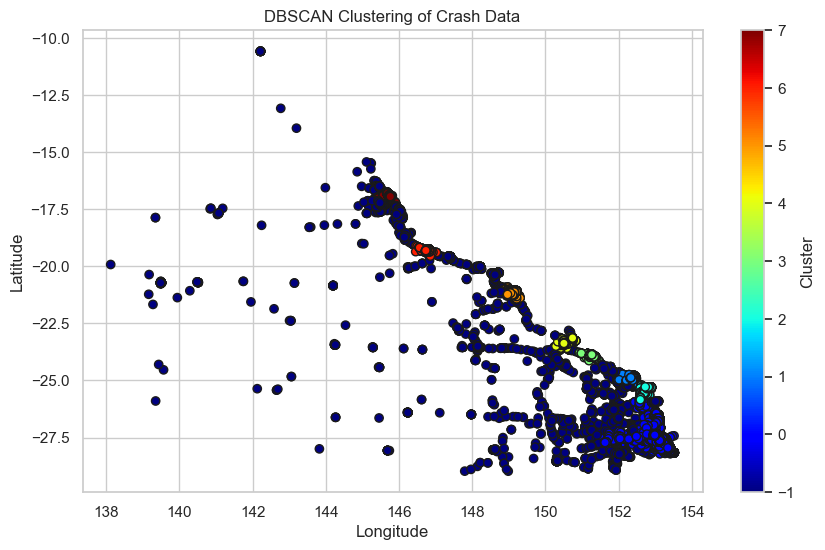

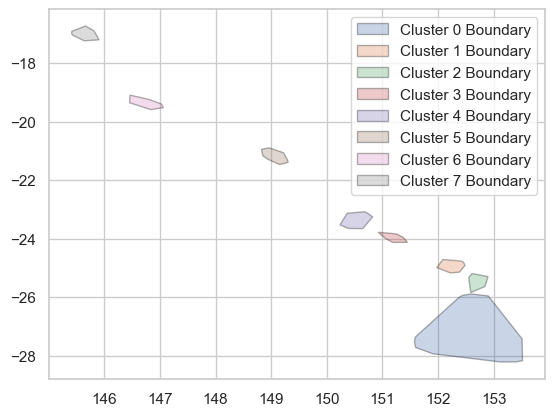

In [ ]:

# use combined dataset
df = df_cd
# select latitude and longitude be the feture
coords = df[['Latitude', 'Longitude']].values
# DBSCAN clustering
epsilon = 20/ 6371.0088  # 0.1km
db = DBSCAN(eps=epsilon, min_samples=500, algorithm='ball_tree', metric='haversine').fit(np.radians(coords))
# result output
labels = db.labels_
num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f'Number of clusters: {num_clusters}')



df['Cluster'] = labels
# modeling evaluation
# 1. silhouette score
if len(set(labels)) > 1:  # more than 1 labels
    silhouette_avg = silhouette_score(np.radians(coords), labels)
    print(f'Silhouette Score: {silhouette_avg:.3f}')
# visualize
plt.figure(figsize=(10, 6))
plt.scatter(df['Longitude'], df['Latitude'], c=df['Cluster'], cmap='jet', marker='o', edgecolor='k')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('DBSCAN Clustering of Crash Data')
plt.colorbar(label='Cluster')
plt.show()
unique_labels = set(labels)
for label in unique_labels:
    if label == -1:
        continue
    
    # get all the point
    cluster_points = df[df['Cluster'] == label][['Longitude', 'Latitude']].values
    if len(cluster_points) >= 3:  # at least point
        # calculate
        hull = MultiPoint([tuple(point) for point in cluster_points]).convex_hull
        # draw the diagram
        if hull.geom_type == 'Polygon':
            x, y = hull.exterior.xy
            plt.fill(x, y, alpha=0.3, edgecolor='black', linewidth=1, label=f'Cluster {label} Boundary')

plt.legend(loc='upper right')
plt.show()

In [ ]:
def get_centermost_point(cluster):
    centroid = (MultiPoint(cluster).centroid.x, MultiPoint(cluster).centroid.y)
    centermost_point = min(cluster, key=lambda point: great_circle(point, centroid).m)
    return tuple(centermost_point)

clusters = [coords[labels == n] for n in range(num_clusters)]
centermost_points = [get_centermost_point(cluster) for cluster in clusters]

# location every high risk point
for i, point in enumerate(centermost_points):
    print(f'Cluster {i}: Centermost point is {point}')

Cluster 0: Centermost point is (-27.45908, 153.01496)
Cluster 1: Centermost point is (-24.87867, 152.34123)
Cluster 2: Centermost point is (-25.42468, 152.75546)
Cluster 3: Centermost point is (-23.8731, 151.23796)
Cluster 4: Centermost point is (-23.36002, 150.52325)
Cluster 5: Centermost point is (-21.15127, 149.15505)
Cluster 6: Centermost point is (-19.29138, 146.76197)
Cluster 7: Centermost point is (-16.91363, 145.72092)


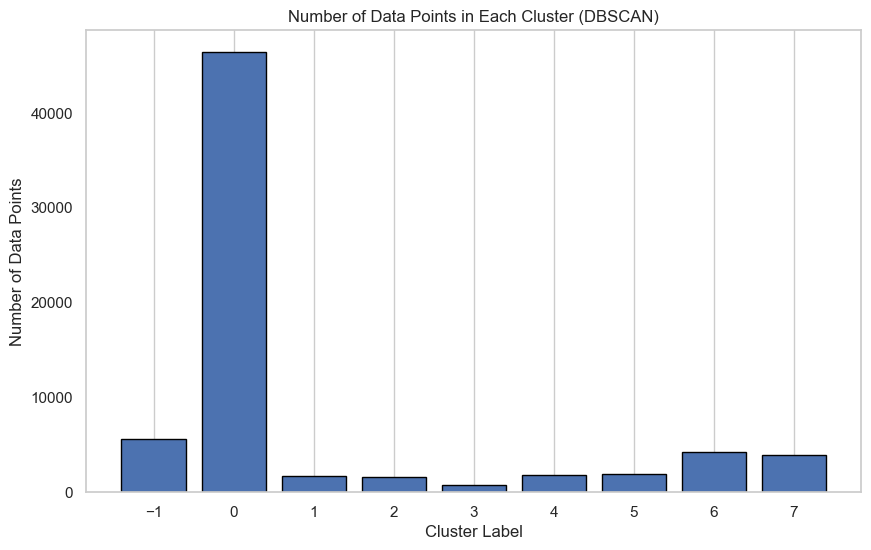

In [ ]:
cluster_counts = df['Cluster'].value_counts().sort_index()

# draw the table
plt.figure(figsize=(10, 6))
plt.bar(cluster_counts.index, cluster_counts.values, edgecolor='black')
plt.xlabel('Cluster Label')
plt.ylabel('Number of Data Points')
plt.title('Number of Data Points in Each Cluster (DBSCAN)')
plt.xticks(cluster_counts.index)  
plt.grid(axis='y')
plt.show()

In [ ]:
#DBSCAN draw the graph
coords = np.array([
    [latitude, longitude] for latitude, longitude in zip(df['Latitude'], df['Longitude'])
])

db = DBSCAN(eps=0.01, min_samples=10).fit(coords)
labels = db.labels_
#noise point
noise = coords[labels == -1]
print(len(noise))

4282


In [ ]:
# import folium
# import matplotlib.pyplot as plt
# import numpy as np

# map = folium.Map(location=[np.mean(noise[:, 0]), np.mean(noise[:, 1])], zoom_start=12)

# # add noise
# for point in noise:
#     folium.CircleMarker(
#         location=[point[0], point[1]],
#         radius=5,  # set point
#         color='red',   
#         fill=True,
#         fill_color='red',   
#         fill_opacity=0.7  
#     ).add_to(map)

# # html file
# map.save('noise_map.html')


In [ ]:
#after future selection
crash_severity_select_column=[]
high_risk_region_select_column=[]
crash_severity_dataset=combined_dataset[crash_severity_select_column]
high_risk_region_dataset=combined_dataset[high_risk_region_select_column]
crash_severity_dataset.to_csv('CrashSeverity_datase.csv', index= False)
high_risk_region_dataset.to_csv('HighRiskRegion_dataset.csv', index= False)
